# Coding project - classification of medical images

The goal of this project is to evaluate your capacity to design a deep learning pipeline for **image** analysis on a real case study, from data processing to interpretation of the model's result. The project accounts for 60% of the course's grade, and will be evaluated as follows:

Criterion | Weight |Details
-------------------|------------------|----------
Quality of the oral  | 30% | Clarity, discussion, ideas for improvement
Coding quality | 30% | Relevant methods, advanced techniques, quality of implementation, reproducibility
Interpretation | 30% | Relevance and quality of interpretation, quality of visual representations
Performance | 10% | Final performance on the classification task of interest

# Predicting invasive ductal carcinoma in tissue slices

## Motivations

Breast cancer is the most common form of cancer in women, and Invasive Ductal Carcinoma (IDC) is the most common subtype of all breast cancers. Accurately identifying IDC is an important clinical task, to assign an aggressiveness rate to a sample. To identify IDC, a biopsy is often done to remove small tissue samples. Then, the tissue sample is visualized by a pathologist, who makes the diagnosis. In the past 10 years, Deep learning tools have been developed to accelerate the time to diagnosis, with automated models which analyze digital images of tissue samples in order to propose a diagnosis. However, several technical challenges remain, in particular to obtain more robust deep learning tools.

## Data set

The original dataset consisted of 162 scanned images of Breast Cancer (BCa) samples. These images are of very high resolution, and thus extremely heavy. Thus, 277,524 patches of size 50 x 50 were extracted, resulting in 198,738 IDC negative and 78,786 IDC positive samples. The original study can be found [here](https://pubmed.ncbi.nlm.nih.gov/27563488/), and examples of resulting image patches are shown below.

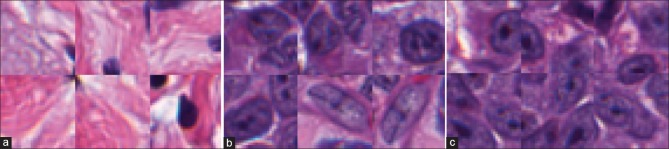




## Set up



Don't forget to change the device to GPU T4

In [ ]:
import torch

### TODO: set the device to "cuda" if a GPU is available, "CPU" otherwise

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

Download the data set using the following code, and check the variable `path` to see where the downloaded folder is located.

In [ ]:
from PIL import Image
from torch.utils.data import Dataset
import os
import numpy as np
import pandas as pd
import kagglehub
from glob import glob
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Path to dataset files: /kaggle/input/breast-histopathology-images


Load the data set, visualize a few samples, store the images and labels in python obkects.

In [ ]:
# Data download should take ~6min
data = glob(os.path.join(path, '**', '*.png'), recursive=True)

In [ ]:
### Voir comment sont nommés les 5 premières images dans les données
for imgname in data[:5]:
    print(imgname)

/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1351_y1101_class0.png
/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1501_y501_class0.png
/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1501_y1101_class0.png
/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x451_y901_class0.png
/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x801_y451_class0.png


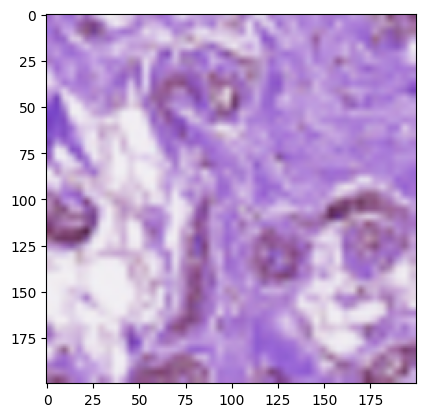

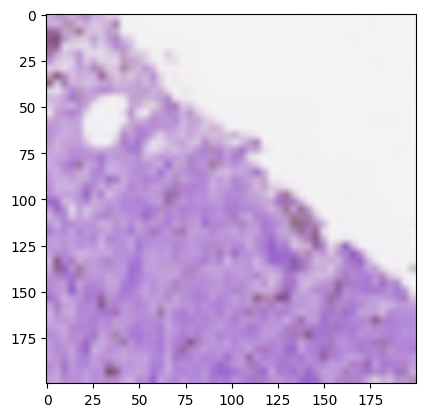

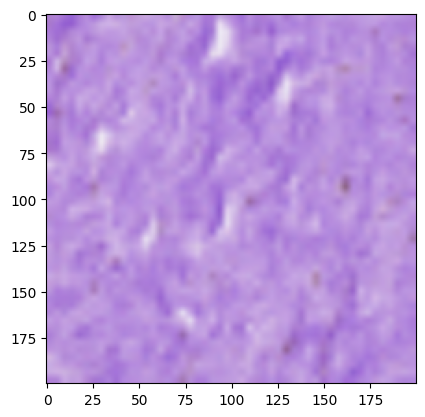

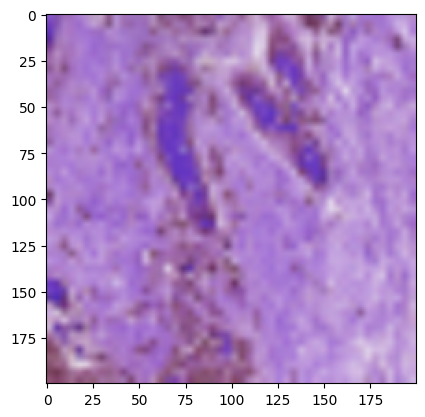

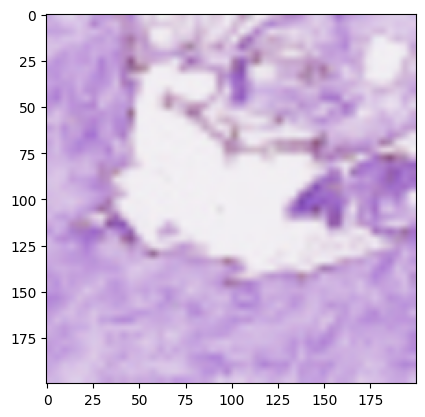

In [ ]:
for i in data[:5]:
    img=cv2.imread(i)
    img_1=cv2.resize(img,(200,200))
    plt.imshow(img_1,cmap='binary')
    plt.show()

In [ ]:
images=[]
labels=[]
# We only consider the 4,000 first images for the sake of computational time
# Feel free to reduce or increase the number of images depending on your resources
idx_choose = np.random.choice(np.arange(len(data)), 4000, replace=False).tolist()

for idx in idx_choose:
    i = data[idx]
    if i.endswith('.png'):
        label=i[-5]
        img=cv2.imread(i)
        img_1=cv2.resize(img,(100,100))
        images.append(img_1)
        labels.append(label)

###  Etape Exploratoire

Distribution des classes:
Classe 0 (Négatif): 2843 échantillons
Classe 1 (Positif): 1157 échantillons
Ratio Positif/Négatif: 0.41


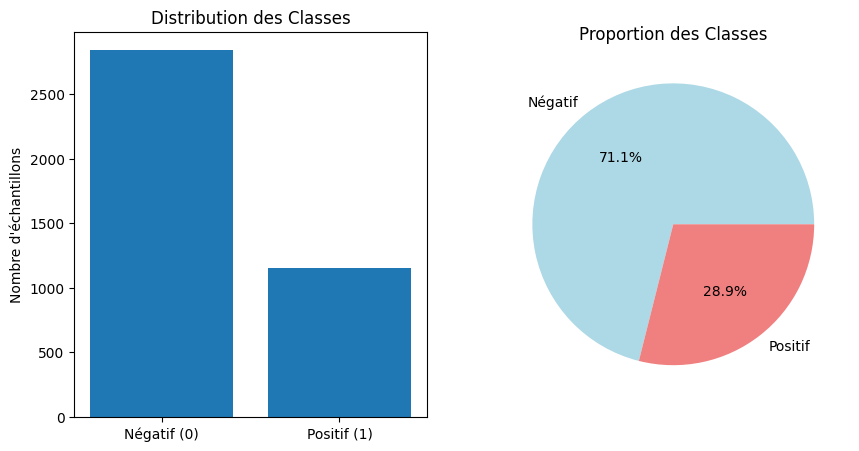


Dimensions des données: (4000, 100, 100, 3)
Valeurs des pixels - Min: 0, Max: 255
Moyenne des pixels: 185.05, Écart-type: 45.21


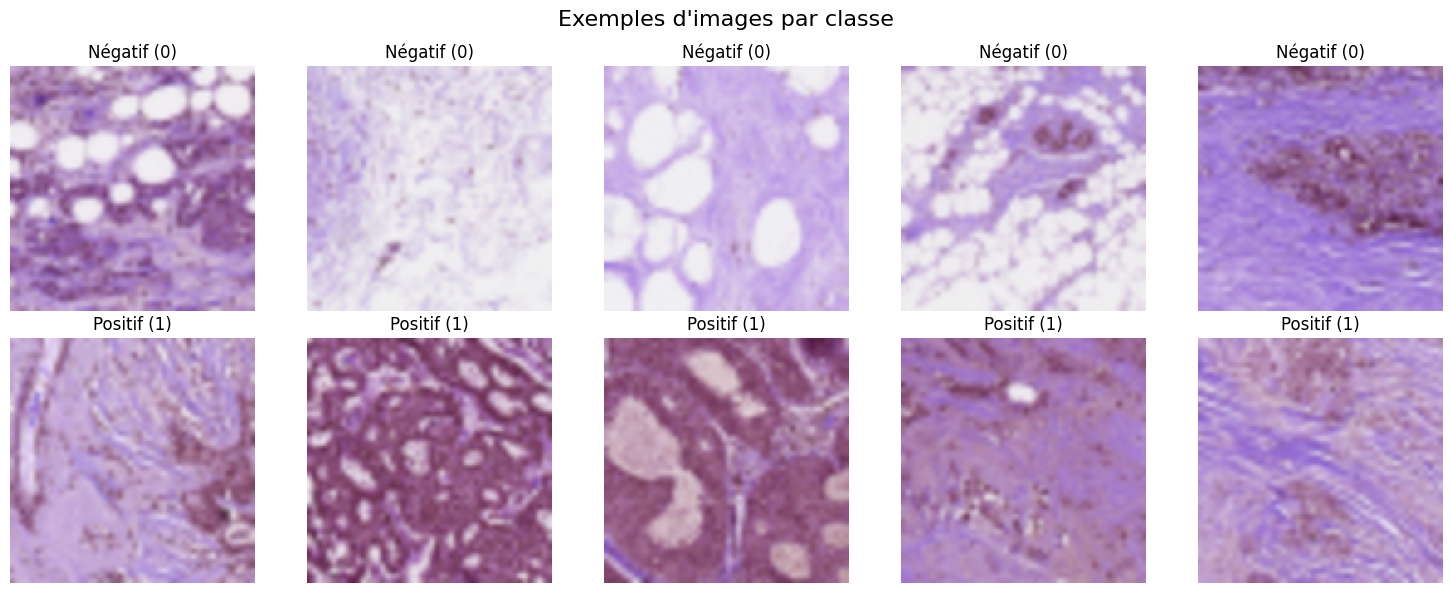

In [ ]:
### Analyse exploratoire
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 1. Analyse de la distribution des classes
labels_int = [int(l) for l in labels]
class_distribution = Counter(labels_int)
print("Distribution des classes:")
print(f"Classe 0 (Négatif): {class_distribution[0]} échantillons")
print(f"Classe 1 (Positif): {class_distribution[1]} échantillons")
print(f"Ratio Positif/Négatif: {class_distribution[1]/class_distribution[0]:.2f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(['Négatif (0)', 'Positif (1)'], [class_distribution[0], class_distribution[1]])
plt.title('Distribution des Classes')
plt.ylabel('Nombre d\'échantillons')

plt.subplot(1, 2, 2)
plt.pie([class_distribution[0], class_distribution[1]],
        labels=['Négatif', 'Positif'],
        autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral'])
plt.title('Proportion des Classes')
plt.show()

# 2. Analyse statistique des images
images_np = np.array(images)
print(f"\nDimensions des données: {images_np.shape}")
print(f"Valeurs des pixels - Min: {images_np.min()}, Max: {images_np.max()}")
print(f"Moyenne des pixels: {images_np.mean():.2f}, Écart-type: {images_np.std():.2f}")

# 3. Visualisation d'exemples par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Exemples négatifs
    neg_idx = np.where(np.array(labels_int) == 0)[0][i]
    axes[0, i].imshow(images[neg_idx])
    axes[0, i].set_title(f'Négatif (0)')
    axes[0, i].axis('off')

    # Exemples positifs
    pos_idx = np.where(np.array(labels_int) == 1)[0][i]
    axes[1, i].imshow(images[pos_idx])
    axes[1, i].set_title(f'Positif (1)')
    axes[1, i].axis('off')

plt.suptitle('Exemples d\'images par classe', fontsize=16)
plt.tight_layout()
plt.show()

L'analyse de la distribution des labels est essentielle pour caractériser le défi de classification. Sur l'échantillon aléatoire de 4000 images, nous observons un déséquilibre de classes significatif.

La classe 0 (IDC Négatif), qui représente les zones de tissu sans cancer canalaire infiltrant, constitue environ  72.2 % de l'échantillon.

La classe 1 (IDC Positif), qui représente les zones avec cancer, ne représente qu'environ 27.8 %.

Les images de tissus sains ("Négatif - 0") sont généralement claires et ordonnées. Elles contiennent souvent des grandes zones blanches (graisse) et les petits points violets (noyaux des cellules) sont rares et bien espacés. Le tissu a une structure normale.

À l'inverse, les images de tissus cancéreux ("Positif - 1") sont foncées et chaotiques. Elles sont envahies par des amas très denses et irréguliers de points violets foncés. Ces amas représentent la masse des cellules cancéreuses qui se multiplient et envahissent le tissu. Le modèle de l'IA doit donc apprendre à distinguer l'ordre (Négatif) du chaos cellulaire dense (Positif).

Nombre total d'images chargées : 4000
Forme (Shape) des images : (100, 100, 3)

--- Répartition des Classes (Labels) ---
Classe 0 (IDC Négatif) : 2843 échantillons (71.08 %)
Classe 1 (IDC Positif) : 1157 échantillons (28.93 %)


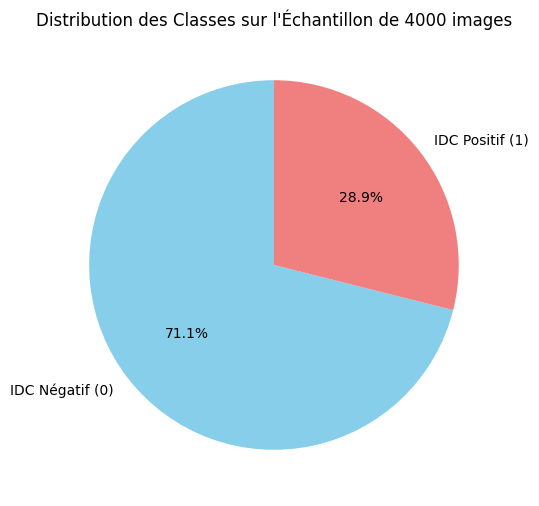

In [ ]:
# Conversion de la liste de labels (strings '0' et '1') en un tableau NumPy d'entiers
labels_np = np.array([int(l) for l in labels])

print(f"Nombre total d'images chargées : {len(images)}")
print(f"Forme (Shape) des images : {images[0].shape}")

# Compter les occurrences de chaque classe
unique, counts = np.unique(labels_np, return_counts=True)
class_counts = dict(zip(unique, counts))

# Calculer les pourcentages
total_images = len(labels_np)
neg_perc = class_counts.get(0, 0) / total_images * 100
pos_perc = class_counts.get(1, 0) / total_images * 100

print("\n--- Répartition des Classes (Labels) ---")
print(f"Classe 0 (IDC Négatif) : {class_counts.get(0, 0)} échantillons ({neg_perc:.2f} %)")
print(f"Classe 1 (IDC Positif) : {class_counts.get(1, 0)} échantillons ({pos_perc:.2f} %)")

# Visualisation sous forme de diagramme circulaire
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=['IDC Négatif (0)', 'IDC Positif (1)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution des Classes sur l\'Échantillon de 4000 images')
plt.show()

### II. Division des données en ensemble d'entraînement, test et validation

In [ ]:
from sklearn.model_selection import train_test_split



# Définition des proportions :
TEST_SIZE = 0.15  # 15% pour l'ensemble de test
VAL_SIZE = 0.15   # 15% pour l'ensemble de validation (15% du reste après le premier split)
                  # Note : Nous allons prendre 15% des 85% restants pour la validation,
                  # ou simplement 15% de l'ensemble total (plus simple pour un premier jet).

# --- Split 1 : Séparation Training/Validation (85%) et Test (15%) ---
# Nous utilisons 'stratify=labels_np' pour conserver la même proportion de classes dans les deux ensembles.
# Le 'random_state' est fixé pour garantir la reproductibilité de la division.
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels_np, test_size=TEST_SIZE, random_state=42, stratify=labels_np
)

# --- Split 2 : Séparation Training (70%) et Validation (15%) à partir de X_temp / y_temp ---
# Nous recalculons le ratio pour obtenir 15% de l'ensemble initial :
# 15 / (100 - 15) = 15 / 85 ≈ 0.1765
val_ratio = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
)

# Afficher les tailles des ensembles
print("\n--- Taille des Ensembles de Données ---")
print(f"Nombre total d'échantillons : {len(images)}")
print(f"Ensemble d'entraînement (Training) : {len(X_train)} images ({len(X_train)/len(images):.1%})")
print(f"Ensemble de validation (Validation) : {len(X_val)} images ({len(X_val)/len(images):.1%})")
print(f"Ensemble de test (Test) : {len(X_test)} images ({len(X_test)/len(images):.1%})")

# Vérification de la stratification (proportion de classe 1)
print("\n--- Vérification de la Stratification (Proportion de la Classe 1) ---")
total_pos_ratio = np.sum(labels_np) / len(labels_np)
train_pos_ratio = np.sum(y_train) / len(y_train)
val_pos_ratio = np.sum(y_val) / len(y_val)
test_pos_ratio = np.sum(y_test) / len(y_test)

print(f"Proportion globale de la classe 1 (Positif) : {total_pos_ratio:.4f}")
print(f"Proportion dans Training : {train_pos_ratio:.4f}")
print(f"Proportion dans Validation : {val_pos_ratio:.4f}")
print(f"Proportion dans Test : {test_pos_ratio:.4f}")


--- Taille des Ensembles de Données ---
Nombre total d'échantillons : 4000
Ensemble d'entraînement (Training) : 2800 images (70.0%)
Ensemble de validation (Validation) : 600 images (15.0%)
Ensemble de test (Test) : 600 images (15.0%)

--- Vérification de la Stratification (Proportion de la Classe 1) ---
Proportion globale de la classe 1 (Positif) : 0.2893
Proportion dans Training : 0.2893
Proportion dans Validation : 0.2883
Proportion dans Test : 0.2900


### Creation des ensembles des données  PyTorch contenant des images et des étiquettes

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

# --- 1. Définition de la Classe Dataset Personnalisée ---
class IDC_Dataset(Dataset):
    """Dataset PyTorch pour les images IDC."""

    def __init__(self, images, labels, transform=None):
        """
        Initialisation du Dataset.
        Args:
            images (list ou np.array): Liste des images (au format NumPy array HxWxC).
            labels (np.array): Tableau des labels (0 ou 1).
            transform (callable, optional): Transformation à appliquer aux échantillons.
        """
        # Conversion explicite des listes d'images en tableau NumPy
        self.images = np.array(images)
        self.labels = np.array(labels, dtype=np.float32) # Labels float pour la fonction de perte (Loss)
        self.transform = transform

    def __len__(self):
        """Retourne la taille du jeu de données."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Récupère l'image et le label à un index donné."""
        # Récupérer l'image et le label
        image = self.images[idx]
        label = self.labels[idx]

        # Appliquer les transformations si elles existent
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# ============================================
# ENTRAÎNEMENT DU MODÈLE BASELINE (SANS AUGMENTATION)
# ============================================

print("\n" + "="*60)
print("1. MODÈLE BASELINE (SANS DATA AUGMENTATION)")
print("="*60)


# Normalisation des valeurs des pixels à l'échelle [0, 1]
X_train_pi = np.array(X_train)/255

# Moyennes et écarts-types typiques pour les images (vous pouvez les calculer plus précisément sur X_train)
MEAN= X_train_pi.mean(axis=(0,1,2))
STD= X_train_pi.std(axis=(0,1,2))

# Formatage pour PyTorch
if np.isscalar(MEAN):  # Scalar si 1 canal
    MEAN = [float(MEAN)]
    STD = [float(STD)]
else:
    MEAN = MEAN.tolist()
    STD = STD.tolist()


# --- 2. Définition des Transformations Standard ---

# Transformations appliquées aux ensembles de Validation et de Test
# Note: Nous utilisons `transforms.ToTensor()` AVANT la normalisation.
# La conversion en PIL Image (Image.fromarray) est nécessaire car `ToTensor` de PyTorch
# est optimisé pour travailler avec des objets PIL ou des tableaux NumPy float.
val_test_transform = transforms.Compose([
    transforms.ToPILImage(), # Convertir le NumPy array en PIL Image (nécessaire pour ToTensor)
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Les transformations d'Augmentation de Données (Data Augmentation) seront ajoutées à l'Étape 2.B
# pour l'ensemble d'Entraînement. Pour l'instant, on utilise le même standard:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# #############

# # Créer les datasets et dataloaders
# train_dataset_baseline = SimpleImageDataset(X_train, y_train, transform=train_transform)
# val_dataset = SimpleImageDataset(X_val, y_val, transform=val_test_transform)

# train_loader_baseline = DataLoader(train_dataset_baseline, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Initialiser et entraîner le modèle baseline
# model_baseline = SimpleCNN().to(device)


# --- 3. Création des Datasets ---
train_dataset = IDC_Dataset(X_train, y_train, transform=train_transform)
val_dataset = IDC_Dataset(X_val, y_val, transform=val_test_transform)
test_dataset = IDC_Dataset(X_test, y_test, transform=val_test_transform)

# --- 4. Création des DataLoaders ---
BATCH_SIZE = 64 # Taille de lot typique pour l'entraînement sur GPU

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Important : Brasser les données d'entraînement
    num_workers=2  # Optionnel : accélérer le chargement des données (dépend de votre environnement)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Ne pas brasser les données de validation/test
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

""" # Vérification du chargement (pour s'assurer que tout fonctionne)
print("\n--- Vérification du Chargement ---")
print(f"Nombre de lots (batches) d'entraînement : {len(train_loader)}")
# Récupérer un lot et vérifier la taille
first_batch_images, first_batch_labels = next(iter(train_loader))
print(f"Taille du premier lot d'images (Batch Size, Channels, Height, Width) : {first_batch_images.shape}")
print(f"Taille du premier lot de labels : {first_batch_labels.shape}")
 """

# --- VÉRIFICATION IMPORTANTE ---
print("\n" + "="*50)
print("VÉRIFICATION DES DONNÉES")
print("="*50)

# Vérifiez un batch de données
for images, labels in train_loader:
    print(f"Shape des images: {images.shape}")  # Devrait être (batch_size, channels, height, width)
    print(f"Type des images: {images.dtype}")
    print(f"Shape des labels: {labels.shape}")
    print(f"Valeurs min/max des images: {images.min():.3f}, {images.max():.3f}")
    break


1. MODÈLE BASELINE (SANS DATA AUGMENTATION)

VÉRIFICATION DES DONNÉES
Shape des images: torch.Size([64, 3, 100, 100])
Type des images: torch.float32
Shape des labels: torch.Size([64])
Valeurs min/max des images: -5.836, 1.746


### Modèle de Base (Baseline CNN)

In [ ]:
import torch.nn.functional as F

In [ ]:
# --- MODELE CNN SIMPLE ---
class SimpleCNN1(nn.Module):
    def __init__(self, num_classes=2, in_channels=3):
        super(SimpleCNN1, self).__init__()

        # Couches convolutives
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # POOLING ADAPTATIF - la solution la plus simple
        # Cela redimensionnera automatiquement à 6x6
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        # Maintenant nous savons que la taille sera: 128 * 6 * 6 = 4608
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Pooling adaptatif garantit la bonne taille
        x = self.adaptive_pool(x)

        #Application (flatten)
        x = x.view(x.size(0), -1)

        # Couches entièrement connectées
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [ ]:
# Détection des canaux

in_channels = X_train[0].shape[2]

# Detection du nombre de classes
num_classes = len(np.unique(y_train))

In [ ]:
# Créez le modèle approprié selon vos données
# Si images RGB:
model_baseline1 = SimpleCNN1(num_classes=num_classes, in_channels=in_channels).to(device)

In [ ]:
print("\n" + "="*50)
print("ARCHITECTURE DU MODÈLE")
print("="*50)
print(model_baseline1)

# --- TEST DU FORWARD PASS ---
print("\n" + "="*50)
print("TEST DU FORWARD PASS")
print("="*50)

model_baseline1.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        print(f"Input shape: {images.shape}")

        # Test avec un seul exemple pour debug
        single_image = images[0:1]  # Prendre juste le premier
        print(f"Single image shape: {single_image.shape}")

        # Test complet
        outputs = model_baseline1(images)
        print(f"Output shape: {outputs.shape}")
        print(f"✓ Forward pass réussi!")
        break


ARCHITECTURE DU MODÈLE
SimpleCNN1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(6, 6))
  (fc1): Linear(in_features=4608, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=2, bias=True)
)

TEST DU FORWARD PASS
Input shape: torch.Size([64, 3, 100, 100])
Single image shape: torch.Size([1, 3, 100, 100])
Output shape: torch.Size([64, 2])
✓ Forward pass réussi!


In [ ]:
# Entrainement du modèle :
def train_model_simple(model, train_loader, val_loader, num_epochs=20, model_name="Baseline", learning_rate=0.001):
    """Entraînement simple avec tracking des métriques"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
baseline_metrics1 = train_model_simple(
    model_baseline1,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline CNN1"
)


ENTRAÎNEMENT: Baseline CNN1
Epoch 1/20: Train Loss: 0.4355, Train Acc: 81.18% | Val Loss: 0.3850, Val Acc: 83.17%
Epoch 2/20: Train Loss: 0.4099, Train Acc: 82.89% | Val Loss: 0.3699, Val Acc: 85.67%
Epoch 3/20: Train Loss: 0.3761, Train Acc: 84.00% | Val Loss: 0.3581, Val Acc: 84.33%
Epoch 4/20: Train Loss: 0.3792, Train Acc: 84.82% | Val Loss: 0.3487, Val Acc: 85.83%
Epoch 5/20: Train Loss: 0.3711, Train Acc: 84.25% | Val Loss: 0.3382, Val Acc: 86.33%
Epoch 6/20: Train Loss: 0.3648, Train Acc: 84.93% | Val Loss: 0.3370, Val Acc: 85.00%
Epoch 7/20: Train Loss: 0.3510, Train Acc: 84.89% | Val Loss: 0.3318, Val Acc: 85.17%
Epoch 8/20: Train Loss: 0.3381, Train Acc: 85.29% | Val Loss: 0.3209, Val Acc: 86.50%
Epoch 9/20: Train Loss: 0.3598, Train Acc: 84.36% | Val Loss: 0.3293, Val Acc: 86.50%
Epoch 10/20: Train Loss: 0.3360, Train Acc: 86.25% | Val Loss: 0.3570, Val Acc: 84.17%
Epoch 11/20: Train Loss: 0.3197, Train Acc: 86.46% | Val Loss: 0.4254, Val Acc: 81.00%
Epoch 12/20: Train Loss

In [ ]:
# Fonction pour visualiser les courbes
def plot_training_curves(train_losses, train_accs, val_losses, val_accs, title):
    """Affiche les courbes de loss et accuracy"""

    epochs = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Courbe de Loss
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss', marker='o')
    axes[0].plot(epochs, val_losses, 'r-', label='Val Loss', marker='o')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Courbe d'Accuracy
    axes[1].plot(epochs, train_accs, 'b-', label='Train Accuracy', marker='o')
    axes[1].plot(epochs, val_accs, 'r-', label='Val Accuracy', marker='o')
    axes[1].set_title(f'Accuracy - {title}')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

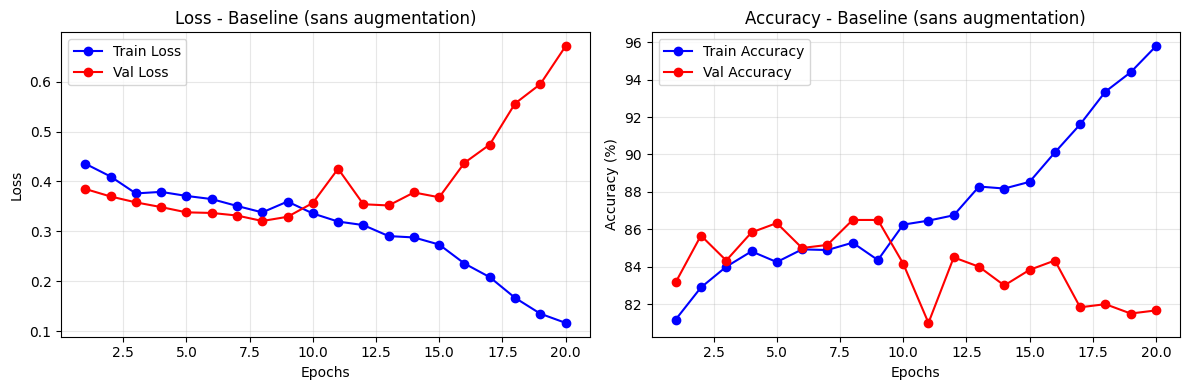

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics1[0], baseline_metrics1[1],
    baseline_metrics1[2], baseline_metrics1[3],
    "Baseline (sans augmentation)"
)

In [ ]:
# --- MODELE CNN SIMPLE Avec le dropout ---
class SimpleCNN2(nn.Module):
    def __init__(self, num_classes=2, in_channels=3,dropout_rate=0.5):
        super(SimpleCNN2, self).__init__()

        # Couches convolutives
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # POOLING ADAPTATIF - la solution la plus simple
        # Cela redimensionnera automatiquement à 6x6
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        # Maintenant nous savons que la taille sera: 128 * 6 * 6 = 4608
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Pooling adaptatif garantit la bonne taille
        x = self.adaptive_pool(x)

        # Debug
        # print(f"Shape après adaptive pool: {x.shape}")
        # Devrait être: (batch, 128, 6, 6)

        #Application (flatten)
        x = x.view(x.size(0), -1)

        # Couches entièrement connectées
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [ ]:
# Creatio du modèle 2
# Si images RGB:
model_baseline2 = SimpleCNN2(num_classes=num_classes, in_channels=in_channels).to(device)

In [ ]:
print("\n" + "="*50)
print("ARCHITECTURE DU MODÈLE")
print("="*50)
print(model_baseline2)

# --- TEST DU FORWARD PASS ---
print("\n" + "="*50)
print("TEST DU FORWARD PASS")
print("="*50)

model_baseline2.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        print(f"Input shape: {images.shape}")

        # Test avec un seul exemple pour debug
        single_image = images[0:1]  # Prendre juste le premier
        print(f"Single image shape: {single_image.shape}")

        # Test complet
        outputs = model_baseline2(images)
        print(f"Output shape: {outputs.shape}")
        print(f"✓ Forward pass réussi!")
        break


ARCHITECTURE DU MODÈLE
SimpleCNN2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(6, 6))
  (fc1): Linear(in_features=4608, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=2, bias=True)
)

TEST DU FORWARD PASS
Input shape: torch.Size([64, 3, 100, 100])
Single image shape: torch.Size([1, 3, 100, 100])
Output shape: torch.Size([64, 2])
✓ Forward pass réussi!


In [ ]:
baseline_metrics2 = train_model_simple(
    model_baseline2,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline CNN2"
)


ENTRAÎNEMENT: Baseline CNN2
Epoch 1/20: Train Loss: 0.4537, Train Acc: 78.93% | Val Loss: 0.3972, Val Acc: 83.00%
Epoch 2/20: Train Loss: 0.4230, Train Acc: 82.86% | Val Loss: 0.3974, Val Acc: 83.50%
Epoch 3/20: Train Loss: 0.3886, Train Acc: 83.89% | Val Loss: 0.3454, Val Acc: 84.67%
Epoch 4/20: Train Loss: 0.3859, Train Acc: 84.75% | Val Loss: 0.3374, Val Acc: 86.17%
Epoch 5/20: Train Loss: 0.3846, Train Acc: 84.54% | Val Loss: 0.3298, Val Acc: 85.33%
Epoch 6/20: Train Loss: 0.3682, Train Acc: 84.82% | Val Loss: 0.3340, Val Acc: 85.50%
Epoch 7/20: Train Loss: 0.3605, Train Acc: 85.11% | Val Loss: 0.3548, Val Acc: 85.83%
Epoch 8/20: Train Loss: 0.3500, Train Acc: 85.75% | Val Loss: 0.3423, Val Acc: 84.17%
Epoch 9/20: Train Loss: 0.3475, Train Acc: 85.36% | Val Loss: 0.3410, Val Acc: 84.83%
Epoch 10/20: Train Loss: 0.3446, Train Acc: 86.11% | Val Loss: 0.3498, Val Acc: 82.83%
Epoch 11/20: Train Loss: 0.3314, Train Acc: 86.61% | Val Loss: 0.3401, Val Acc: 85.00%
Epoch 12/20: Train Loss

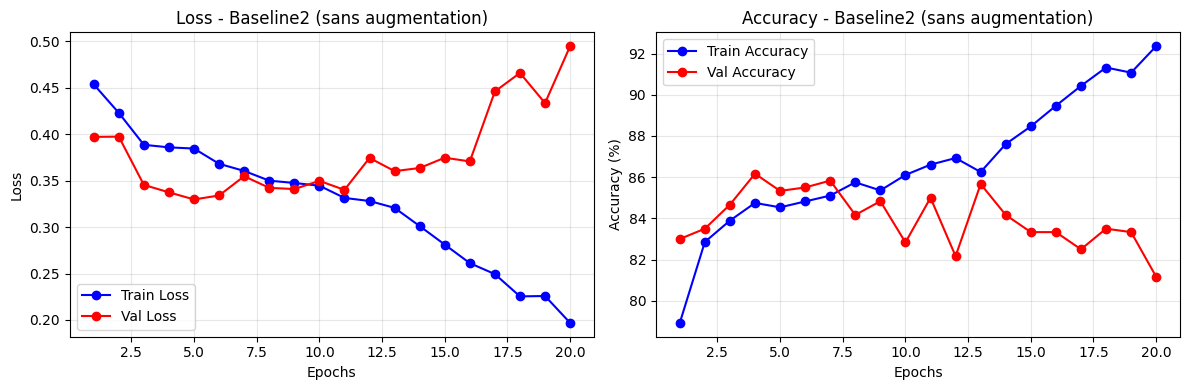

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics2[0], baseline_metrics2[1],
    baseline_metrics2[2], baseline_metrics2[3],
    "Baseline2 (sans augmentation)"
)

### Data Amélioration

In [ ]:
import numpy as np
import cv2
import random

# Initialiser les listes pour stocker les images et labels
images = []
labels = []

# Définir le nombre d'images total que vous voulez
total_images = 15000   # Vous pouvez ajuster ce nombre
images_per_class = total_images // 2  # 2000 par classe

# Séparer les images par classe
cancer_imgs = []
non_cancer_imgs = []

for img_path in data:
    if img_path.endswith('.png'):
        label = img_path[-5]  # Le label est le 5ème caractère depuis la fin
        if label == '0':
            non_cancer_imgs.append(img_path)
        elif label == '1':
            cancer_imgs.append(img_path)

print(f"Nombre d'images non-cancéreuses disponibles: {len(non_cancer_imgs)}")
print(f"Nombre d'images cancéreuses disponibles: {len(cancer_imgs)}")

# Vérifier qu'on a assez d'images de chaque classe
available_cancer = len(cancer_imgs)
available_non_cancer = len(non_cancer_imgs)

# Ajuster le nombre si nécessaire (prendre le minimum disponible)
actual_images_per_class = min(images_per_class, available_cancer, available_non_cancer)
actual_total = actual_images_per_class * 2

print(f"Images par classe: {actual_images_per_class}")
print(f"Total d'images: {actual_total}")

# Sélectionner aléatoirement un nombre équilibré d'images de chaque classe
if actual_images_per_class > 0:
    # Mélanger les listes
    random.shuffle(cancer_imgs)
    random.shuffle(non_cancer_imgs)

    # Sélectionner les images pour chaque classe
    selected_cancer = cancer_imgs[:actual_images_per_class]
    selected_non_cancer = non_cancer_imgs[:actual_images_per_class]

    # Combiner et mélanger
    selected_imgs = selected_cancer + selected_non_cancer
    selected_labels = ['1'] * actual_images_per_class + ['0'] * actual_images_per_class

    # Mélanger ensemble (images et labels)
    combined = list(zip(selected_imgs, selected_labels))
    random.shuffle(combined)
    selected_imgs, selected_labels = zip(*combined)

    # Charger et prétraiter les images
    for img_path, label in zip(selected_imgs, selected_labels):
        img = cv2.imread(img_path)
        if img is not None:  # Vérifier que l'image a été chargée correctement
            img_resized = cv2.resize(img, (100, 100))
            images.append(img_resized)
            labels.append(label)

    print(f"Images chargées: {len(images)}")
    print(f"Distribution des labels: {labels.count('0')} non-cancéreux, {labels.count('1')} cancéreux")

    # Vérification
    if labels.count('0') == labels.count('1'):
        print("✅ Distribution parfaitement équilibrée!")
    else:
        print(f"⚠️ Distribution: {labels.count('0')} vs {labels.count('1')}")
else:
    print("Pas assez d'images pour créer un dataset équilibré!")

Nombre d'images non-cancéreuses disponibles: 397476
Nombre d'images cancéreuses disponibles: 157572
Images par classe: 7500
Total d'images: 15000
Images chargées: 15000
Distribution des labels: 7500 non-cancéreux, 7500 cancéreux
✅ Distribution parfaitement équilibrée!


Distribution des classes:
Classe 0 (Négatif): 7500 échantillons
Classe 1 (Positif): 7500 échantillons
Ratio Positif/Négatif: 1.00


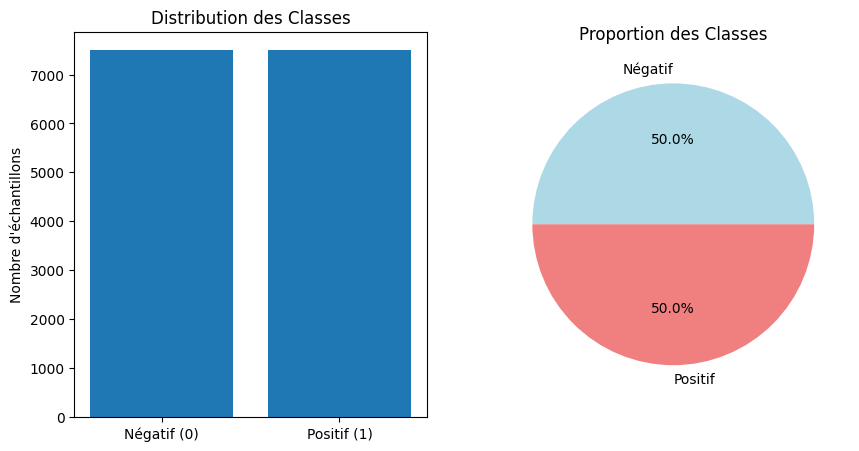


Dimensions des données: (15000, 100, 100, 3)
Valeurs des pixels - Min: 3, Max: 255
Moyenne des pixels: 179.51, Écart-type: 45.09


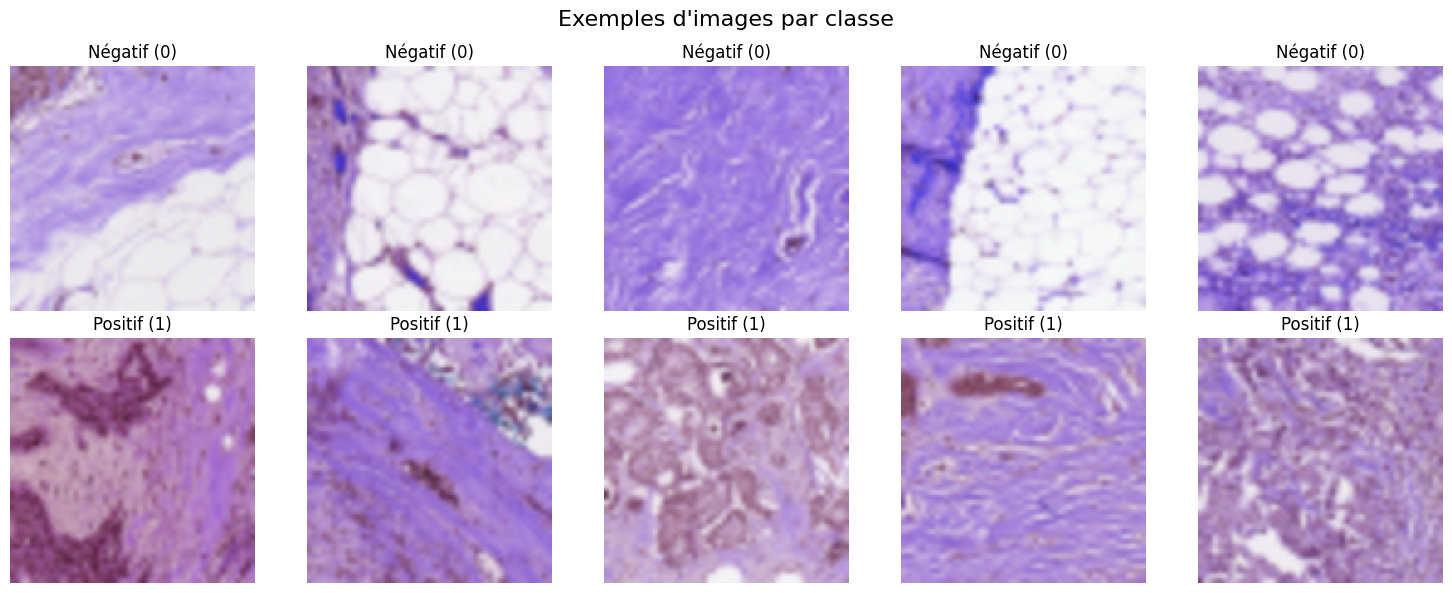

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 1. Analyse de la distribution des classes
labels_int = [int(l) for l in labels]
class_distribution = Counter(labels_int)
print("Distribution des classes:")
print(f"Classe 0 (Négatif): {class_distribution[0]} échantillons")
print(f"Classe 1 (Positif): {class_distribution[1]} échantillons")
print(f"Ratio Positif/Négatif: {class_distribution[1]/class_distribution[0]:.2f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(['Négatif (0)', 'Positif (1)'], [class_distribution[0], class_distribution[1]])
plt.title('Distribution des Classes')
plt.ylabel('Nombre d\'échantillons')

plt.subplot(1, 2, 2)
plt.pie([class_distribution[0], class_distribution[1]],
        labels=['Négatif', 'Positif'],
        autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral'])
plt.title('Proportion des Classes')
plt.show()

# 2. Analyse statistique des images
images_np = np.array(images)
print(f"\nDimensions des données: {images_np.shape}")
print(f"Valeurs des pixels - Min: {images_np.min()}, Max: {images_np.max()}")
print(f"Moyenne des pixels: {images_np.mean():.2f}, Écart-type: {images_np.std():.2f}")

# 3. Visualisation d'exemples par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Exemples négatifs
    neg_idx = np.where(np.array(labels_int) == 0)[0][i]
    axes[0, i].imshow(images[neg_idx])
    axes[0, i].set_title(f'Négatif (0)')
    axes[0, i].axis('off')

    # Exemples positifs
    pos_idx = np.where(np.array(labels_int) == 1)[0][i]
    axes[1, i].imshow(images[pos_idx])
    axes[1, i].set_title(f'Positif (1)')
    axes[1, i].axis('off')

plt.suptitle('Exemples d\'images par classe', fontsize=16)
plt.tight_layout()
plt.show()

Nombre total d'images chargées : 15000
Forme (Shape) des images : (100, 100, 3)

--- Répartition des Classes (Labels) ---
Classe 0 (IDC Négatif) : 7500 échantillons (50.00 %)
Classe 1 (IDC Positif) : 7500 échantillons (50.00 %)


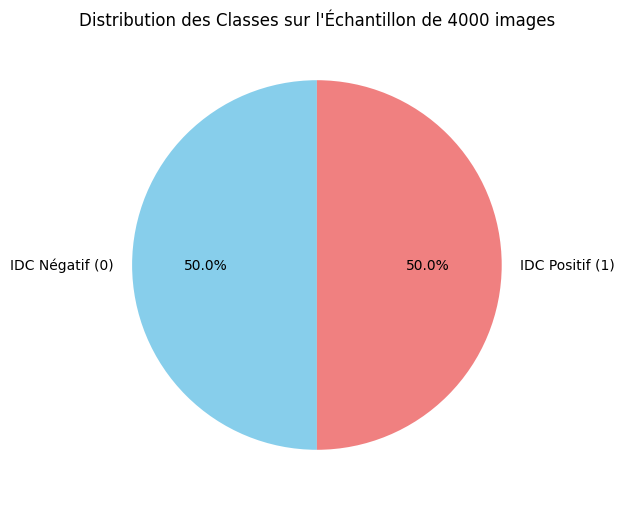

In [ ]:
# Conversion de la liste de labels (strings '0' et '1') en un tableau NumPy d'entiers
labels_np = np.array([int(l) for l in labels])

print(f"Nombre total d'images chargées : {len(images)}")
print(f"Forme (Shape) des images : {images[0].shape}")

# Compter les occurrences de chaque classe
unique, counts = np.unique(labels_np, return_counts=True)
class_counts = dict(zip(unique, counts))

# Calculer les pourcentages
total_images = len(labels_np)
neg_perc = class_counts.get(0, 0) / total_images * 100
pos_perc = class_counts.get(1, 0) / total_images * 100

print("\n--- Répartition des Classes (Labels) ---")
print(f"Classe 0 (IDC Négatif) : {class_counts.get(0, 0)} échantillons ({neg_perc:.2f} %)")
print(f"Classe 1 (IDC Positif) : {class_counts.get(1, 0)} échantillons ({pos_perc:.2f} %)")

# Visualisation sous forme de diagramme circulaire
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=['IDC Négatif (0)', 'IDC Positif (1)'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution des Classes sur l\'Échantillon de 4000 images')
plt.show()

In [ ]:

## Division des données en test et entrainement pour les données reequilibrés

from sklearn.model_selection import train_test_split

# Assurez-vous que 'images' est une liste ou un tableau NumPy, et 'labels_np' est le tableau des labels numériques (0 ou 1) de l'étape 1.A.

# Définition des proportions :
TEST_SIZE = 0.15  # 15% pour l'ensemble de test
VAL_SIZE = 0.15   # 15% pour l'ensemble de validation (15% du reste après le premier split)
                  # Note : Nous allons prendre 15% des 85% restants pour la validation,
                  # ou simplement 15% de l'ensemble total (plus simple pour un premier jet).

# --- Split 1 : Séparation Training/Validation (85%) et Test (15%) ---
# Nous utilisons 'stratify=labels_np' pour conserver la même proportion de classes dans les deux ensembles.
# Le 'random_state' est fixé pour garantir la reproductibilité de la division.
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels_np, test_size=TEST_SIZE, random_state=42, stratify=labels_np
)

# --- Split 2 : Séparation Training (70%) et Validation (15%) à partir de X_temp / y_temp ---
# Nous recalculons le ratio pour obtenir 15% de l'ensemble initial :
# 15 / (100 - 15) = 15 / 85 ≈ 0.1765
val_ratio = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
)

# Afficher les tailles des ensembles
print("\n--- Taille des Ensembles de Données ---")
print(f"Nombre total d'échantillons : {len(images)}")
print(f"Ensemble d'entraînement (Training) : {len(X_train)} images ({len(X_train)/len(images):.1%})")
print(f"Ensemble de validation (Validation) : {len(X_val)} images ({len(X_val)/len(images):.1%})")
print(f"Ensemble de test (Test) : {len(X_test)} images ({len(X_test)/len(images):.1%})")

# Vérification de la stratification (proportion de classe 1)
print("\n--- Vérification de la Stratification (Proportion de la Classe 1) ---")
total_pos_ratio = np.sum(labels_np) / len(labels_np)
train_pos_ratio = np.sum(y_train) / len(y_train)
val_pos_ratio = np.sum(y_val) / len(y_val)
test_pos_ratio = np.sum(y_test) / len(y_test)

print(f"Proportion globale de la classe 1 (Positif) : {total_pos_ratio:.4f}")
print(f"Proportion dans Training : {train_pos_ratio:.4f}")
print(f"Proportion dans Validation : {val_pos_ratio:.4f}")
print(f"Proportion dans Test : {test_pos_ratio:.4f}")


--- Taille des Ensembles de Données ---
Nombre total d'échantillons : 15000
Ensemble d'entraînement (Training) : 10500 images (70.0%)
Ensemble de validation (Validation) : 2250 images (15.0%)
Ensemble de test (Test) : 2250 images (15.0%)

--- Vérification de la Stratification (Proportion de la Classe 1) ---
Proportion globale de la classe 1 (Positif) : 0.5000
Proportion dans Training : 0.5000
Proportion dans Validation : 0.5000
Proportion dans Test : 0.5000


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np

# --- 1. Définition de la Classe Dataset Personnalisée ---
class IDC_DatasetAm(Dataset):
    """Dataset PyTorch pour les images IDC."""

    def __init__(self, images, labels, transform=None):
        """
        Initialisation du Dataset.
        Args:
            images (list ou np.array): Liste des images (au format NumPy array HxWxC).
            labels (np.array): Tableau des labels (0 ou 1).
            transform (callable, optional): Transformation à appliquer aux échantillons.
        """
        # Conversion explicite des listes d'images en tableau NumPy
        self.images = np.array(images)
        self.labels = np.array(labels, dtype=np.float32) # Labels float pour la fonction de perte (Loss)
        self.transform = transform

    def __len__(self):
        """Retourne la taille du jeu de données."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Récupère l'image et le label à un index donné."""
        # Récupérer l'image et le label
        image = self.images[idx]
        label = self.labels[idx]

        # Appliquer les transformations si elles existent
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import numpy as np
import cv2
import random

# ============================================
# ENTRAÎNEMENT DU MODÈLE BASELINE (AVEC AUGMENTATION)
# ============================================

print("\n" + "="*60)
print("1. MODÈLE BASELINE (AVEC DATA AUGMENTATION)")
print("="*60)


# Normalisation des valeurs des pixels à l'échelle [0, 1]
X_train_pi = np.array(X_train)/255

# Moyennes et écarts-types typiques pour les images (vous pouvez les calculer plus précisément sur X_train)
MEAN= X_train_pi.mean(axis=(0,1,2))
STD= X_train_pi.std(axis=(0,1,2))

# Formatage pour PyTorch
if np.isscalar(MEAN):  # Scalar si 1 canal
    MEAN = [float(MEAN)]
    STD = [float(STD)]
else:
    MEAN = MEAN.tolist()
    STD = STD.tolist()


# --- 2. Définition des Transformations Standard ---

# Transformations appliquées aux ensembles de Validation et de Test
# Note: Nous utilisons `transforms.ToTensor()` AVANT la normalisation.
# La conversion en PIL Image (Image.fromarray) est nécessaire car `ToTensor` de PyTorch
# est optimisé pour travailler avec des objets PIL ou des tableaux NumPy float.
val_test_transform = transforms.Compose([
    transforms.ToPILImage(), # Convertir le NumPy array en PIL Image (nécessaire pour ToTensor)
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])



# Les transformations d'Augmentation de Données (Data Augmentation) ont été ajustéés avec data transformations
train_transform = transforms.Compose([
    transforms.ToPILImage(), # Moved to the beginning
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])


# --- 3. Création des Datasets ---
train_dataset = IDC_DatasetAm(X_train, y_train, transform=train_transform)
val_dataset = IDC_DatasetAm(X_val, y_val, transform=val_test_transform)
test_dataset = IDC_DatasetAm(X_test, y_test, transform=val_test_transform)

# --- 4. Création des DataLoaders ---
BATCH_SIZE = 64 # Taille de lot typique pour l'entraînement sur GPU

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Important : Brasser les données d'entraînement
    num_workers=2  # Optionnel : accélérer le chargement des données (dépend de votre environnement)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # Ne pas brasser les données de validation/test
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

""" # Vérification du chargement (pour s'assurer que tout fonctionne)
print("\n--- Vérification du Chargement ---")
print(f"Nombre de lots (batches) d'entraînement : {len(train_loader)}")
# Récupérer un lot et vérifier la taille
first_batch_images, first_batch_labels = next(iter(train_loader))
print(f"Taille du premier lot d'images (Batch Size, Channels, Height, Width) : {first_batch_images.shape}")
print(f"Taille du premier lot de labels : {first_batch_labels.shape}")
 """

# --- VÉRIFICATION IMPORTANTE ---
print("\n" + "="*50)
print("VÉRIFICATION DES DONNÉES")
print("="*50)

# Vérifiez un batch de données
for images, labels in train_loader:
    print(f"Shape des images: {images.shape}")  # Devrait être (batch_size, channels, height, width)
    print(f"Type des images: {images.dtype}")
    print(f"Shape des labels: {labels.shape}")
    print(f"Valeurs min/max des images: {images.min():.3f}, {images.max():.3f}")
    break


1. MODÈLE BASELINE (AVEC DATA AUGMENTATION)

VÉRIFICATION DES DONNÉES
Shape des images: torch.Size([64, 3, 100, 100])
Type des images: torch.float32
Shape des labels: torch.Size([64])
Valeurs min/max des images: -5.684, 2.035


In [ ]:
# Entrainement du modèle :
def train_model_simple_aug(model, train_loader, val_loader, num_epochs=20, model_name="Baseline", learning_rate=0.001):
    """Entraînement simple avec tracking des métriques"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
import torch.nn.functional as F

In [ ]:
# --- MODELE CNN Ameliore avec Augmentation ---
class SimpleCNN2(nn.Module):
    def __init__(self, num_classes=2, in_channels=3,dropout_rate=0.5):
        super(SimpleCNN2, self).__init__()
        # Couches convolutives
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # POOLING ADAPTATIF - la solution la plus simple
        # Cela redimensionnera automatiquement à 6x6
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        # Maintenant nous savons que la taille sera: 128 * 6 * 6 = 4608
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Pooling adaptatif garantit la bonne taille
        x = self.adaptive_pool(x)

        # Debug
        # print(f"Shape après adaptive pool: {x.shape}")
        # Devrait être: (batch, 128, 6, 6)

        #Application (flatten)
        x = x.view(x.size(0), -1)

        # Couches entièrement connectées
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [ ]:
# Créez le modèle approprié selon vos données
# Si images RGB:
model_baseline2_aug = SimpleCNN2(num_classes=num_classes, in_channels=in_channels).to(device)

In [ ]:
baseline_metrics2_aug = train_model_simple_aug(
    model_baseline2_aug,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline CNN2 amelioré avec augmentation"
)


ENTRAÎNEMENT: Baseline CNN2 amelioré avec augmentation
Epoch 1/20: Train Loss: 0.4806, Train Acc: 79.73% | Val Loss: 0.4698, Val Acc: 80.53%
Epoch 2/20: Train Loss: 0.4464, Train Acc: 81.02% | Val Loss: 0.5080, Val Acc: 77.20%
Epoch 3/20: Train Loss: 0.4424, Train Acc: 81.30% | Val Loss: 0.4087, Val Acc: 82.84%
Epoch 4/20: Train Loss: 0.4150, Train Acc: 82.26% | Val Loss: 0.4013, Val Acc: 83.02%
Epoch 5/20: Train Loss: 0.4104, Train Acc: 82.82% | Val Loss: 0.3864, Val Acc: 83.56%
Epoch 6/20: Train Loss: 0.4044, Train Acc: 82.62% | Val Loss: 0.3862, Val Acc: 83.02%
Epoch 7/20: Train Loss: 0.3901, Train Acc: 83.50% | Val Loss: 0.3896, Val Acc: 83.91%
Epoch 8/20: Train Loss: 0.3901, Train Acc: 83.64% | Val Loss: 0.3766, Val Acc: 83.78%
Epoch 9/20: Train Loss: 0.3881, Train Acc: 83.70% | Val Loss: 0.4242, Val Acc: 82.62%
Epoch 10/20: Train Loss: 0.3797, Train Acc: 84.29% | Val Loss: 0.3933, Val Acc: 82.27%
Epoch 11/20: Train Loss: 0.3825, Train Acc: 84.35% | Val Loss: 0.3833, Val Acc: 84.

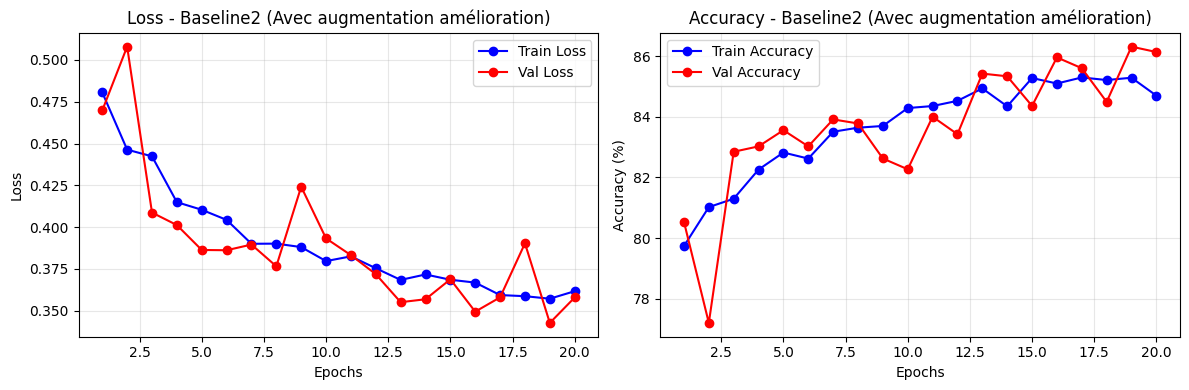

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics2_aug[0], baseline_metrics2_aug[1],
    baseline_metrics2_aug[2], baseline_metrics2_aug[3],
    "Baseline2 (Avec augmentation amélioration)"
)

### Modele Avec earning stop: C'est le CNN2 qui serait entrainé avec une nouvelle fonction d'entrainement en utilisant le early stopping

In [ ]:
# Entrainement du modèle :
def train_model_3(model, train_loader, val_loader, num_epochs=20, model_name="Baseline 3",
                  learning_rate=0.001, use_scheduler=True, factor_rate=0.5, patience_=3):
    """Entraînement amélioré avec scheduler et early stopping"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)#, weight_decay=1e-4)

    # Learning rate scheduler
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=factor_rate, patience=patience_, min_lr=1e-6
        )
    else:
        scheduler = None

    # Stockage des métriques
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    # Stockage de l'historique du learning rate
    lr_history = []
    lr_update_points = []

    # Early stopping
    best_val_acc = 0.0
    best_model_state = None
    patience = 10
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*60}")
    print(f"Learning rate: {learning_rate}")
    print(f"Early stopping patience: {patience}")
    print(f"Using scheduler: {use_scheduler}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # NB: Régularisation L2 est déjà incluse via weight_decay dans l'optimizer

            loss.backward()

            # Gradient clipping pour éviter l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Affichage progressif
            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Mise à jour du scheduler
        if scheduler is not None:
            scheduler.step(val_loss)


        # Early stopping et sauvegarde du meilleur modèle
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"Nouveau meilleur modèle: {val_acc:.2f}%")
        else:
            patience_counter += 1

        # Affichage des résultats
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")

        # Vérification du critère d'arrêt précoce
        if patience_counter >= patience:
            print(f"\nEarly stopping déclenché après {epoch+1} epochs!")
            break
    # Charger le meilleur modèle avant de retourner
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Meilleur modèle restauré avec une précision de validation de {best_val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
# Créez le modèle approprié selon vos données
# Si images RGB:
model_baseline3_t = SimpleCNN2(num_classes=num_classes, in_channels=in_channels,
                              dropout_rate=0.5).to(device)

In [ ]:
baseline_metrics2_aug_earming_stop = train_model_3(
    model_baseline3_t ,
    train_loader,
    val_loader,
    num_epochs=20,
    factor_rate=0.5, patience_=3,
    learning_rate=1e-3,
    model_name="Baseline CNN2 amelioré avec augmentation et earling stop"
)


ENTRAÎNEMENT: Baseline CNN2 amelioré avec augmentation et earling stop
Learning rate: 0.001
Early stopping patience: 10
Using scheduler: True
  Batch 20/165, Loss: 0.4507
  Batch 40/165, Loss: 0.3903
  Batch 60/165, Loss: 0.4149
  Batch 80/165, Loss: 0.4549
  Batch 100/165, Loss: 0.6242
  Batch 120/165, Loss: 0.4450
  Batch 140/165, Loss: 0.4800
  Batch 160/165, Loss: 0.3483
Nouveau meilleur modèle: 81.38%
Epoch 1/20: Train Loss: 0.4834, Train Acc: 78.48% | Val Loss: 0.4234, Val Acc: 81.38% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.3556
  Batch 40/165, Loss: 0.4231
  Batch 60/165, Loss: 0.4192
  Batch 80/165, Loss: 0.3901
  Batch 100/165, Loss: 0.5009
  Batch 120/165, Loss: 0.3663
  Batch 140/165, Loss: 0.3283
  Batch 160/165, Loss: 0.7912
Nouveau meilleur modèle: 82.62%
Epoch 2/20: Train Loss: 0.4295, Train Acc: 81.53% | Val Loss: 0.4169, Val Acc: 82.62% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.4308
  Batch 40/165, Loss: 0.3614
  Batch 60/165, Loss: 0.429

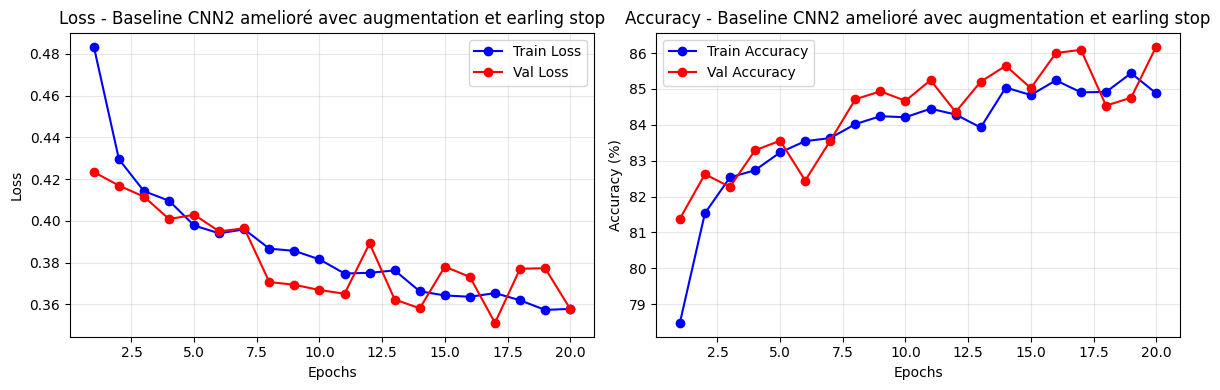

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics2_aug_earming_stop[0], baseline_metrics2_aug_earming_stop[1],
    baseline_metrics2_aug_earming_stop[2], baseline_metrics2_aug_earming_stop[3],
    "Baseline CNN2 amelioré avec augmentation et earling stop"
)

##### CHANGER LE MODÈLE POUR CELUI AVEC AUGMENTATION

Utilisation d'un simple CNN3 en ajoutant le Batch Normalisation

In [ ]:

# --- MODELE CNN Ameliore avec Augmentation ---
class SimpleCNN3(nn.Module):
    def __init__(self, num_classes=2, in_channels=3, dropout_rate=0.3):
        super(SimpleCNN3, self).__init__()

        # Couches convolutives
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Batch Normalization
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

        self.bn_fc1 = nn.BatchNorm1d(512)
        self.bn_fc2 = nn.BatchNorm1d(256)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate + 0.1)

        # POOLING ADAPTATIF - la solution la plus simple
        # Cela redimensionnera automatiquement à 6x6
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        # Maintenant nous savons que la taille sera: 256 * 6 * 6 = 4608
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        # Initialisation des poids
        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Couches convolutives avec BatchNorm

        ## Bloc 1
        x= F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.dropout(x)

        ## Bloc 2
        x= F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)

        ## Bloc 3
        x= F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = self.dropout(x)

        ## Bloc 4
        x= F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)
        x = self.dropout(x)

        # Pooling adaptatif garantit la bonne taille
        x = self.adaptive_pool(x)

        # Debug
        # print(f"Shape après adaptive pool: {x.shape}")
        # Devrait être: (batch, 128, 6, 6)

        #Application (flatten)
        x = x.view(x.size(0), -1)

        # Couches entièrement connectées
        x= F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x= F.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.fc3(x)

        return x

In [ ]:
# Détection des canaux

in_channels = X_train[0].shape[2]

# Detection du nombre de classes
num_classes = len(np.unique(y_train))

In [ ]:
# Entrainement du modèle :
def train_model_3(model, train_loader, val_loader, num_epochs=20, model_name="Baseline 3",
                  learning_rate=0.001, use_scheduler=True, factor_rate=0.5, patience_=3):
    """Entraînement amélioré avec scheduler et early stopping"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)#, weight_decay=1e-4)

    # Learning rate scheduler
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=factor_rate, patience=patience_, min_lr=1e-6
        )
    else:
        scheduler = None

    # Stockage des métriques
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    # Stockage de l'historique du learning rate
    lr_history = []
    lr_update_points = []

    # Early stopping
    best_val_acc = 0.0
    best_model_state = None
    patience = 7
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*60}")
    print(f"Learning rate: {learning_rate}")
    print(f"Early stopping patience: {patience}")
    print(f"Using scheduler: {use_scheduler}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # NB: Régularisation L2 est déjà incluse via weight_decay dans l'optimizer

            loss.backward()

            # Gradient clipping pour éviter l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Affichage progressif
            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Mise à jour du scheduler
        if scheduler is not None:
            scheduler.step(val_loss)


        # Early stopping et sauvegarde du meilleur modèle
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"Nouveau meilleur modèle: {val_acc:.2f}%")
        else:
            patience_counter += 1

        # Affichage des résultats
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")

        # Vérification du critère d'arrêt précoce
        if patience_counter >= patience:
            print(f"\nEarly stopping déclenché après {epoch+1} epochs!")
            break
    # Charger le meilleur modèle avant de retourner
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Meilleur modèle restauré avec une précision de validation de {best_val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
# Créez le modèle approprié selon vos données
# Si images RGB:
model_baseline3 = SimpleCNN3(num_classes=num_classes, in_channels=in_channels).to(device)

In [ ]:
print("\n" + "="*50)
print("ARCHITECTURE DU MODÈLE")
print("="*50)
print(model_baseline3)

# --- TEST DU FORWARD PASS ---
print("\n" + "="*50)
print("TEST DU FORWARD PASS")
print("="*50)

model_baseline3.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        print(f"Input shape: {images.shape}")

        # Test avec un seul exemple pour debug
        single_image = images[0:1]  # Prendre juste le premier
        print(f"Single image shape: {single_image.shape}")

        # Test complet
        outputs = model_baseline3(images)
        print(f"Output shape: {outputs.shape}")
        print(f"✓ Forward pass réussi!")
        break


ARCHITECTURE DU MODÈLE
SimpleCNN3(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_fc1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_fc2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [ ]:
baseline_metrics_amel_3 = train_model_3(
    model_baseline3,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline Model amélioré 3"
)


ENTRAÎNEMENT: Baseline Model amélioré 3
Learning rate: 0.001
Early stopping patience: 7
Using scheduler: True
  Batch 20/165, Loss: 0.4509
  Batch 40/165, Loss: 0.4613
  Batch 60/165, Loss: 0.5110
  Batch 80/165, Loss: 0.4027
  Batch 100/165, Loss: 0.4469
  Batch 120/165, Loss: 0.4237
  Batch 140/165, Loss: 0.3061
  Batch 160/165, Loss: 0.4375
Nouveau meilleur modèle: 81.42%
Epoch 1/20: Train Loss: 0.4654, Train Acc: 79.32% | Val Loss: 0.4314, Val Acc: 81.42% | LR: 0.001000 | Patience: 0/7
  Batch 20/165, Loss: 0.4688
  Batch 40/165, Loss: 0.4535
  Batch 60/165, Loss: 0.3645
  Batch 80/165, Loss: 0.2649
  Batch 100/165, Loss: 0.4561
  Batch 120/165, Loss: 0.4546
  Batch 140/165, Loss: 0.3023
  Batch 160/165, Loss: 0.3892
Nouveau meilleur modèle: 82.40%
Epoch 2/20: Train Loss: 0.4343, Train Acc: 81.30% | Val Loss: 0.4025, Val Acc: 82.40% | LR: 0.001000 | Patience: 0/7
  Batch 20/165, Loss: 0.3279
  Batch 40/165, Loss: 0.5205
  Batch 60/165, Loss: 0.5303
  Batch 80/165, Loss: 0.2544
  B

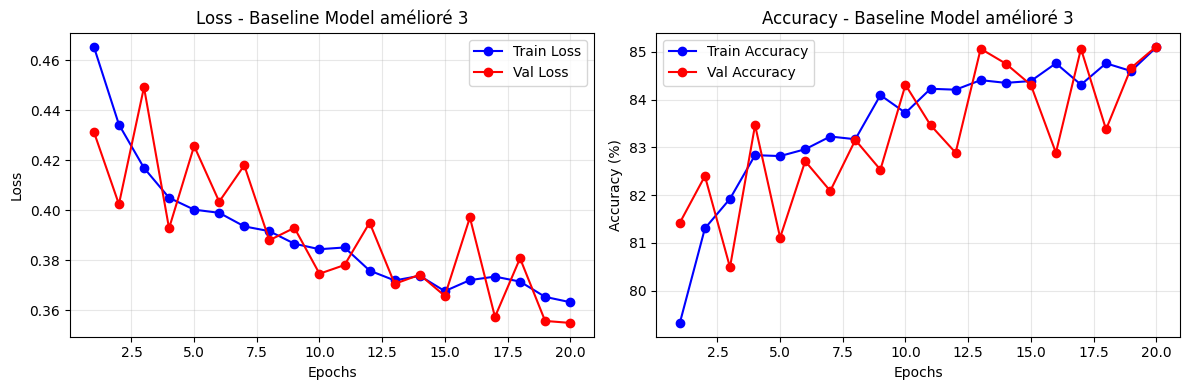

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics_amel_3[0], baseline_metrics_amel_3[1],
    baseline_metrics_amel_3[2], baseline_metrics_amel_3[3],
    "Baseline Model amélioré 3"
)

### Les deux dernières modèles il faut qu'on test avec optimiseur adamsmithW

In [ ]:
# Entrainement du modèle :
def train_model_3_adam_W(model, train_loader, val_loader, num_epochs=20, model_name="Baseline 3",
                  learning_rate=0.001, use_scheduler=True, factor_rate=0.5, patience_=3):
    """Entraînement amélioré avec scheduler et early stopping"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # Learning rate scheduler
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=factor_rate, patience=patience_, min_lr=1e-6
        )
    else:
        scheduler = None

    # Stockage des métriques
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    # Stockage de l'historique du learning rate
    lr_history = []
    lr_update_points = []

    # Early stopping
    best_val_acc = 0.0
    best_model_state = None
    patience = 10
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*60}")
    print(f"Learning rate: {learning_rate}")
    print(f"Early stopping patience: {patience}")
    print(f"Using scheduler: {use_scheduler}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # NB: Régularisation L2 est déjà incluse via weight_decay dans l'optimizer

            loss.backward()

            # Gradient clipping pour éviter l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Affichage progressif
            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Mise à jour du scheduler
        if scheduler is not None:
            scheduler.step(val_loss)


        # Early stopping et sauvegarde du meilleur modèle
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"Nouveau meilleur modèle: {val_acc:.2f}%")
        else:
            patience_counter += 1

        # Affichage des résultats
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")

        # Vérification du critère d'arrêt précoce
        if patience_counter >= patience:
            print(f"\nEarly stopping déclenché après {epoch+1} epochs!")
            break
    # Charger le meilleur modèle avant de retourner
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Meilleur modèle restauré avec une précision de validation de {best_val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
# Créez le modèle avec earling stop adamW data augmentation
# Si images RGB:
model_baseline3_t_Adam = SimpleCNN2(num_classes=num_classes, in_channels=in_channels,
                              dropout_rate=0.5).to(device)

In [ ]:
baseline_metrics2_aug_earming_stop_AdamW = train_model_3_adam_W(
    model_baseline3_t_Adam ,
    train_loader,
    val_loader,
    num_epochs=20,
    factor_rate=0.5, patience_=3,
    learning_rate=1e-3,
    model_name="Baseline CNN2 amelioré avec augmentation et earling stop en utilisant AdamW"
)


ENTRAÎNEMENT: Baseline CNN2 amelioré avec augmentation et earling stop en utilisant AdamW
Learning rate: 0.001
Early stopping patience: 10
Using scheduler: True
  Batch 20/165, Loss: 0.5485
  Batch 40/165, Loss: 0.3783
  Batch 60/165, Loss: 0.5480
  Batch 80/165, Loss: 0.5931
  Batch 100/165, Loss: 0.4509
  Batch 120/165, Loss: 0.5491
  Batch 140/165, Loss: 0.4574
  Batch 160/165, Loss: 0.4379
Nouveau meilleur modèle: 81.07%
Epoch 1/20: Train Loss: 0.4894, Train Acc: 78.83% | Val Loss: 0.4730, Val Acc: 81.07% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.3586
  Batch 40/165, Loss: 0.3226
  Batch 60/165, Loss: 0.4379
  Batch 80/165, Loss: 0.3341
  Batch 100/165, Loss: 0.4949
  Batch 120/165, Loss: 0.4366
  Batch 140/165, Loss: 0.4405
  Batch 160/165, Loss: 0.6146
Nouveau meilleur modèle: 81.33%
Epoch 2/20: Train Loss: 0.4421, Train Acc: 81.51% | Val Loss: 0.4363, Val Acc: 81.33% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.3898
  Batch 40/165, Loss: 0.4746
  Batch 

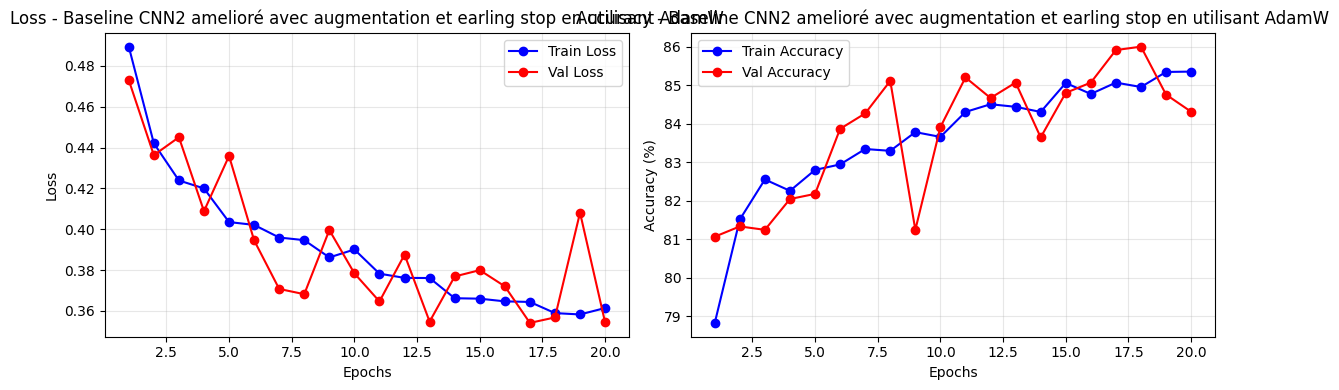

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics2_aug_earming_stop_AdamW[0], baseline_metrics2_aug_earming_stop_AdamW[1],
    baseline_metrics2_aug_earming_stop_AdamW[2], baseline_metrics2_aug_earming_stop_AdamW[3],
    "Baseline CNN2 amelioré avec augmentation et earling stop en utilisant AdamW"
)

In [ ]:
# Créez le modèle approprié selon vos données
# Si images RGB:
model_baseline3_AdamW = SimpleCNN3(num_classes=num_classes, in_channels=in_channels).to(device)

In [ ]:
baseline_metrics_amel_3_AdamW = train_model_3_adam_W(
    model_baseline3_AdamW,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline Model amélioré avec Batch earling stop et optimiseur adamW"
)


ENTRAÎNEMENT: Baseline Model amélioré avec Batch earling stop et optimiseur adamW
Learning rate: 0.001
Early stopping patience: 10
Using scheduler: True
  Batch 20/165, Loss: 0.6245
  Batch 40/165, Loss: 0.3407
  Batch 60/165, Loss: 0.4661
  Batch 80/165, Loss: 0.4904
  Batch 100/165, Loss: 0.4198
  Batch 120/165, Loss: 0.5174
  Batch 140/165, Loss: 0.3507
  Batch 160/165, Loss: 0.4045
Nouveau meilleur modèle: 81.87%
Epoch 1/20: Train Loss: 0.4552, Train Acc: 79.56% | Val Loss: 0.4386, Val Acc: 81.87% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.5044
  Batch 40/165, Loss: 0.3584
  Batch 60/165, Loss: 0.5315
  Batch 80/165, Loss: 0.4203
  Batch 100/165, Loss: 0.3509
  Batch 120/165, Loss: 0.4542
  Batch 140/165, Loss: 0.5166
  Batch 160/165, Loss: 0.4053
Nouveau meilleur modèle: 83.47%
Epoch 2/20: Train Loss: 0.4265, Train Acc: 81.58% | Val Loss: 0.3958, Val Acc: 83.47% | LR: 0.001000 | Patience: 0/10
  Batch 20/165, Loss: 0.3955
  Batch 40/165, Loss: 0.4200
  Batch 60/165, 

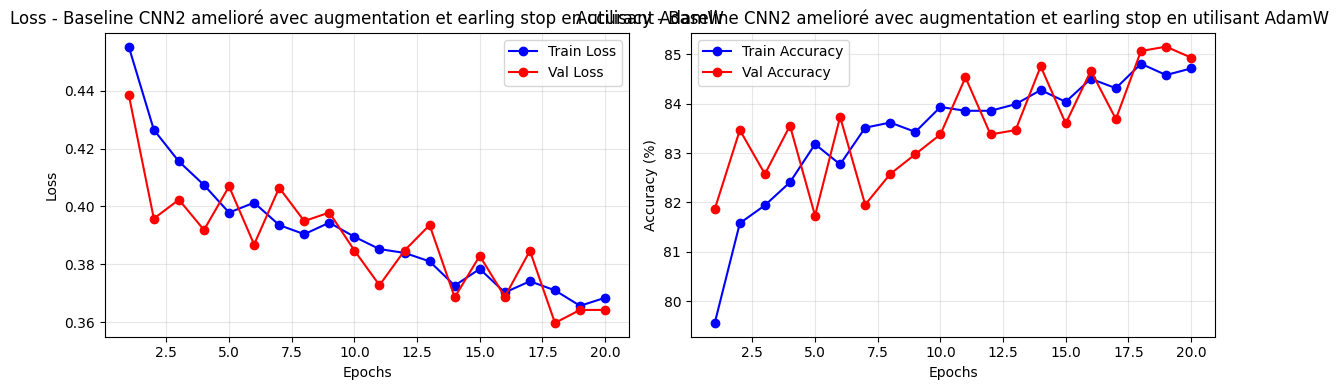

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics_amel_3_AdamW[0], baseline_metrics_amel_3_AdamW[1],
    baseline_metrics_amel_3_AdamW[2], baseline_metrics_amel_3_AdamW[3],
    "Baseline CNN2 amelioré avec augmentation et earling stop en utilisant AdamW"
)

-----------------

### Modèle prentrainée RESNET18

In [ ]:
# Utilisation d'un modèle pré-entraîné (ResNet18)
class PretrainedResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(PretrainedResNet, self).__init__()
        self.model = models.resnet18(pretrained=True)

        # Geler les premières couches
        for param in self.model.parameters():
            param.requires_grad = False

        # Modifier la dernière couche
        num_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:

# Detection du nombre de classes
num_classes = len(np.unique(y_train))

In [ ]:
# Créez le modèle approprié selon vos données
model_Reset18 = PretrainedResNet(num_classes=num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


In [ ]:
print("\n" + "="*50)
print("ARCHITECTURE DU MODÈLE")
print("="*50)
print(model_Reset18)

# --- TEST DU FORWARD PASS ---
print("\n" + "="*50)
print("TEST DU FORWARD PASS")
print("="*50)

model_Reset18.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        print(f"Input shape: {images.shape}")

        # Test avec un seul exemple pour debug
        single_image = images[0:1]  # Prendre juste le premier
        print(f"Single image shape: {single_image.shape}")

        # Test complet
        outputs = model_Reset18(images)
        print(f"Output shape: {outputs.shape}")
        print(f"✓ Forward pass réussi!")
        break


ARCHITECTURE DU MODÈLE
PretrainedResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momen

In [ ]:
# Fonction pour entrainer le modele RESET18 :
def ResNet18_model_epochs(model, train_loader, val_loader, num_epochs=20, model_name="Baseline 2", learning_rate=0.001):
    """Entraînement simple avec tracking des métriques"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)#, weight_decay=1e-4)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
baseline_metrics_RESET18 = ResNet18_model_epochs(
    model_Reset18,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline Model RESNET18"
)


ENTRAÎNEMENT: Baseline Model RESNET18
Epoch 1/20: Train Loss: 0.5144, Train Acc: 75.86% | Val Loss: 0.5210, Val Acc: 77.02%
Epoch 2/20: Train Loss: 0.4703, Train Acc: 78.64% | Val Loss: 0.4899, Val Acc: 78.84%
Epoch 3/20: Train Loss: 0.4649, Train Acc: 78.95% | Val Loss: 0.5196, Val Acc: 75.24%
Epoch 4/20: Train Loss: 0.4586, Train Acc: 79.55% | Val Loss: 0.4718, Val Acc: 78.89%
Epoch 5/20: Train Loss: 0.4558, Train Acc: 80.04% | Val Loss: 0.4753, Val Acc: 78.53%
Epoch 6/20: Train Loss: 0.4524, Train Acc: 80.00% | Val Loss: 0.4623, Val Acc: 79.69%
Epoch 7/20: Train Loss: 0.4393, Train Acc: 80.31% | Val Loss: 0.4555, Val Acc: 79.64%
Epoch 8/20: Train Loss: 0.4341, Train Acc: 80.59% | Val Loss: 0.4766, Val Acc: 79.24%
Epoch 9/20: Train Loss: 0.4353, Train Acc: 81.05% | Val Loss: 0.4455, Val Acc: 80.27%
Epoch 10/20: Train Loss: 0.4398, Train Acc: 80.16% | Val Loss: 0.4585, Val Acc: 80.58%
Epoch 11/20: Train Loss: 0.4344, Train Acc: 80.94% | Val Loss: 0.4499, Val Acc: 80.58%
Epoch 12/20: 

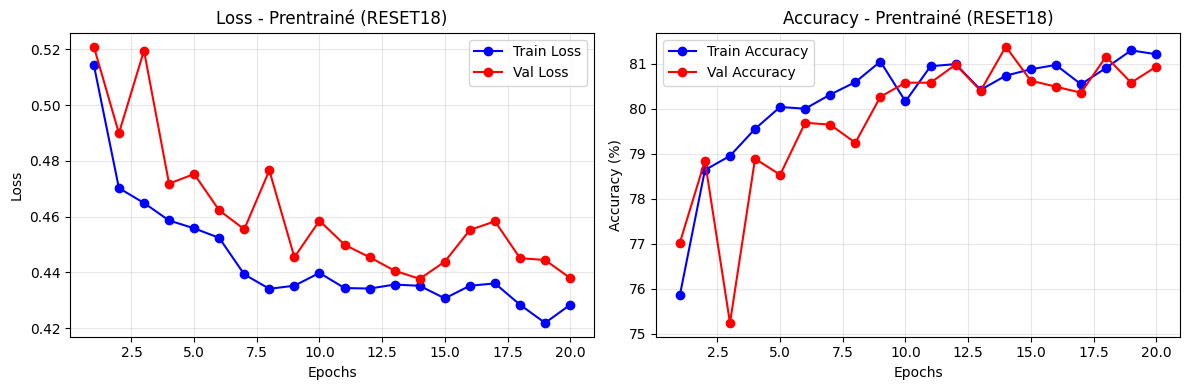

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics_RESET18[0], baseline_metrics_RESET18[1],
    baseline_metrics_RESET18[2], baseline_metrics_RESET18[3],
    "Prentrainé (RESET18)"
)

### Modèle Entrainée  VGG

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class VGGAdapted(nn.Module):
    """
    VGG adapté pour les petites images (50x50) - CORRIGÉ
    - Sortie en logits bruts.
    - Sortie adaptée pour 2 classes (compatible avec CrossEntropyLoss).
    """
    def __init__(self, num_output_classes=2, dropout_rate=0.5):
        super(VGGAdapted, self).__init__()

        # --- Feature Extractor (Partie Convolutive) ---
        # Charger VGG16 avec les poids pré-entraînés par défaut
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Utiliser les 10 premières couches (jusqu'à la fin du deuxième bloc MaxPool)
        # L'output de cette séquence a 128 canaux.
        self.features = nn.Sequential(
            *list(vgg.features.children())[:10]
        )

        # Geler les features (Transfer Learning)
        for param in self.features.parameters():
            param.requires_grad = False

        # Pooling adaptatif pour fixer la taille spatiale à 4x4
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))

        # Taille du vecteur après aplatissement : 128 canaux * 4 * 4 = 2048
        FLATTENED_SIZE = 128 * 4 * 4

        # --- Classifier (Couches Fully Connected) ---
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(FLATTENED_SIZE, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            # LIGNE CRITIQUE : Produit 2 logits bruts (pour IDC Positif et Négatif)
            nn.Linear(256, num_output_classes)
            # AUCUNE activation finale (Sigmoid/Softmax) !
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [ ]:
# Detection du nombre de classes
num_classes = len(np.unique(y_train))

In [ ]:
# Notre modele selon selon nos données
model_VGG = VGGAdapted(num_output_classes=num_classes).to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 107MB/s]


In [ ]:
print("\n" + "="*50)
print("ARCHITECTURE DU MODÈLE")
print("="*50)
print(model_VGG)

# --- TEST DU FORWARD PASS ---
print("\n" + "="*50)
print("TEST DU FORWARD PASS")
print("="*50)

model_VGG.eval()
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        print(f"Input shape: {images.shape}")

        # Test avec un seul exemple pour debug
        single_image = images[0:1]  # Prendre juste le premier
        print(f"Single image shape: {single_image.shape}")

        # Test complet
        outputs = model_VGG(images)
        print(f"Output shape: {outputs.shape}")
        print(f"✓ Forward pass réussi!")
        break


ARCHITECTURE DU MODÈLE
VGGAdapted(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=2048, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU(inplace=True)
    (6): Dropo

In [ ]:
# Fonction pour entrainer le model VGG  sur nos données  :
def VGG_model_epochs(model, train_loader, val_loader, num_epochs=20, model_name="Baseline VGG", learning_rate=0.001):
    """Entraînement simple avec tracking des métriques"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)#, weight_decay=1e-4)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*50}")

    for epoch in range(num_epochs):
        # Entraînement
        model.train()
        running_loss = correct = total = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        val_loss = val_correct = val_total = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # ASSUREZ-VOUS QUE LES LABELS SONT DE TYPE LONG
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

In [ ]:
baseline_metrics_VGG = VGG_model_epochs(
    model_VGG,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Baseline Model VGG"
)


ENTRAÎNEMENT: Baseline Model VGG
Epoch 1/20: Train Loss: 0.6236, Train Acc: 71.74% | Val Loss: 0.4639, Val Acc: 80.58%
Epoch 2/20: Train Loss: 0.5012, Train Acc: 77.99% | Val Loss: 0.4724, Val Acc: 81.02%
Epoch 3/20: Train Loss: 0.4960, Train Acc: 78.07% | Val Loss: 0.4692, Val Acc: 81.38%
Epoch 4/20: Train Loss: 0.4795, Train Acc: 78.00% | Val Loss: 0.4765, Val Acc: 80.53%
Epoch 5/20: Train Loss: 0.4804, Train Acc: 78.48% | Val Loss: 0.4540, Val Acc: 81.33%
Epoch 6/20: Train Loss: 0.4883, Train Acc: 78.01% | Val Loss: 0.5217, Val Acc: 81.07%
Epoch 7/20: Train Loss: 0.4776, Train Acc: 78.30% | Val Loss: 0.4598, Val Acc: 81.07%
Epoch 8/20: Train Loss: 0.4735, Train Acc: 78.92% | Val Loss: 0.4611, Val Acc: 81.64%
Epoch 9/20: Train Loss: 0.4826, Train Acc: 78.56% | Val Loss: 0.4721, Val Acc: 81.20%
Epoch 10/20: Train Loss: 0.4742, Train Acc: 79.01% | Val Loss: 0.4650, Val Acc: 81.78%
Epoch 11/20: Train Loss: 0.4672, Train Acc: 79.35% | Val Loss: 0.4574, Val Acc: 81.16%
Epoch 12/20: Train

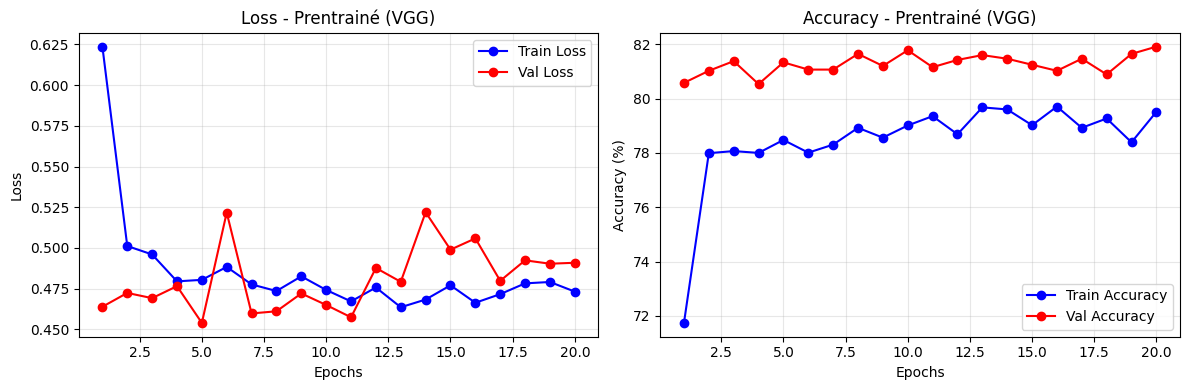

In [ ]:
# Visualiser les résultats
plot_training_curves(
    baseline_metrics_VGG[0], baseline_metrics_VGG[1],
    baseline_metrics_VGG[2], baseline_metrics_VGG[3],
    "Prentrainé (VGG)"
)

### Construction d'un modèle transformer pour ce projet

Définissons un  TransformerBlock:
Implémentons un bloc Transformer standard, comprenant une auto-attention multi-têtes, une normalisation de couche et un réseau feed-forward avec connexions résiduelles et dropout.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout_rate=0.1):
        super().__init__()
        # Layer Normalization for the attention block
        self.norm1 = nn.LayerNorm(embed_dim)
        # Multi-Head Self-Attention layer
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True)
        # Dropout for the attention output
        self.dropout1 = nn.Dropout(dropout_rate)

        # Layer Normalization for the Feed-Forward Network (FFN) block
        self.norm2 = nn.LayerNorm(embed_dim)
        # Feed-Forward Network (FFN)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        # Apply first LayerNorm
        norm_x = self.norm1(x)
        # Multi-Head Self-Attention with residual connection and dropout
        attn_output, _ = self.attn(norm_x, norm_x, norm_x) # (query, key, value)
        x = x + self.dropout1(attn_output)

        # Apply second LayerNorm
        norm_x = self.norm2(x)
        # Feed-Forward Network with residual connection
        mlp_output = self.mlp(norm_x)
        x = x + mlp_output

        return x

Création de  l'architecture Vision Transformer (ViT). Cela implique : 1. L'intégration de patchs (conversion de patchs d'images en intégrations linéaires). 2. L'ajout d'un jeton de classe apprenable. 3. L'ajout d'intégrations positionnelles. 4. L'empilement de plusieurs blocs Transformer. 5. Une tête MLP finale pour la classification.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        num_classes,
        embed_dim,
        num_heads,
        mlp_ratio,
        num_blocks,
        dropout_rate=0.1
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.embed_dim = embed_dim

        # 1. Patch embedding
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # 2. Learnable class token
        self.class_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # 3. Positional embeddings
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

        # Dropout for patch and position embeddings
        self.pos_dropout = nn.Dropout(dropout_rate)

        # 4. Stacking multiple Transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout_rate) for _ in range(num_blocks)]
        )

        # 8. Final Layer Normalization
        self.norm = nn.LayerNorm(embed_dim)

        # 9. MLP head for classification
        self.mlp_head = nn.Linear(embed_dim, num_classes)

        # Initialize weights (optional, but good practice)
        nn.init.trunc_normal_(self.class_token, std=.02)
        nn.init.trunc_normal_(self.position_embeddings, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        # 10.a. Patch embedding and flatten
        # (batch_size, in_channels, img_size, img_size) -> (batch_size, embed_dim, num_patches_h, num_patches_w)
        x = self.patch_embed(x)
        # (batch_size, embed_dim, num_patches_h, num_patches_w) -> (batch_size, num_patches, embed_dim)
        x = x.flatten(2).transpose(1, 2)

        # 10.b. Expand class token and concatenate with patch embeddings
        # class_token: (1, 1, embed_dim) -> (batch_size, 1, embed_dim)
        batch_size = x.shape[0]
        class_token = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((class_token, x), dim=1) # (batch_size, num_patches + 1, embed_dim)

        # 10.c. Add positional embeddings
        x = x + self.position_embeddings
        x = self.pos_dropout(x)

        # 10.d. Pass through Transformer blocks
        x = self.transformer_blocks(x)

        # 10.e. Apply final LayerNorm
        x = self.norm(x)

        # 10.f. Extract the class token's output
        # This is the output corresponding to the class token (first element in the sequence)
        class_token_output = x[:, 0]

        # 10.g. Pass through MLP head
        logits = self.mlp_head(class_token_output)

        return logits

Preparation VIT pour l'entrainement

In [ ]:
import torch.nn as nn

# 1. Define Vision Transformer hyperparameters
img_size = X_train[0].shape[0] # Assuming images are square (H=W)
patch_size = 10  # A common choice, ensure it divides img_size (100/10 = 10)
embed_dim = 768  # Dimensionality of the token embeddings
num_heads = 12   # Number of attention heads
mlp_ratio = 4    # Ratio of the MLP hidden layer size to embed_dim
num_blocks = 6   # Number of Transformer blocks
dropout_rate = 0.1 # Dropout rate

# in_channels and num_classes are already defined from previous cells
print(f"Image size: {img_size}")
print(f"Input channels: {in_channels}")
print(f"Number of classes: {num_classes}")

# 2. Instantiate the VisionTransformer model
model_vit = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=in_channels,
    num_classes=num_classes,
    embed_dim=embed_dim,
    num_heads=num_heads,
    mlp_ratio=mlp_ratio,
    num_blocks=num_blocks,
    dropout_rate=dropout_rate
).to(device)

print("\n" + "="*50)
print("VISION TRANSFORMER (ViT) MODEL ARCHITECTURE")
print("="*50)
# 3. Print the Vision Transformer model architecture
print(model_vit)

print("\n" + "="*50)
print("TESTING FORWARD PASS FOR ViT")
print("="*50)

# 4. Perform a forward pass test
model_vit.eval() # Set model to evaluation mode
with torch.no_grad():
    # Get a batch of images from the train_loader
    for images, labels in train_loader:
        images = images.to(device)
        print(f"Input batch shape: {images.shape}")

        # Perform forward pass
        outputs = model_vit(images)

        print(f"Output batch shape: {outputs.shape}")
        print(f"✓ ViT forward pass successful!")
        break # Only test with one batch


Image size: 100
Input channels: 3
Number of classes: 2

VISION TRANSFORMER (ViT) MODEL ARCHITECTURE
VisionTransformer(
  (patch_embed): Conv2d(3, 768, kernel_size=(10, 10), stride=(10, 10))
  (pos_dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (dropout1): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=3072, out_features=768, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((768,), eps=1e-05, elemen

Entrainement du modèle et visualisation des resultats


ENTRAÎNEMENT: Vision Transformer
Learning rate: 0.001
Early stopping patience: 7
Using scheduler: True
  Batch 20/165, Loss: 0.5714
  Batch 40/165, Loss: 0.5788
  Batch 60/165, Loss: 0.8642
  Batch 80/165, Loss: 0.5561
  Batch 100/165, Loss: 0.4578
  Batch 120/165, Loss: 0.4405
  Batch 140/165, Loss: 0.4225
  Batch 160/165, Loss: 0.3554
Nouveau meilleur modèle: 78.31%
Epoch 1/20: Train Loss: 0.6334, Train Acc: 72.64% | Val Loss: 0.5203, Val Acc: 78.31% | LR: 0.001000 | Patience: 0/7
  Batch 20/165, Loss: 0.4863
  Batch 40/165, Loss: 0.5572
  Batch 60/165, Loss: 0.6090
  Batch 80/165, Loss: 0.3678
  Batch 100/165, Loss: 0.6306
  Batch 120/165, Loss: 0.5019
  Batch 140/165, Loss: 0.6486
  Batch 160/165, Loss: 0.4019
Epoch 2/20: Train Loss: 0.5057, Train Acc: 76.21% | Val Loss: 0.4976, Val Acc: 75.73% | LR: 0.001000 | Patience: 1/7
  Batch 20/165, Loss: 0.5171
  Batch 40/165, Loss: 0.3244
  Batch 60/165, Loss: 0.4674
  Batch 80/165, Loss: 0.4760
  Batch 100/165, Loss: 0.5210
  Batch 120/

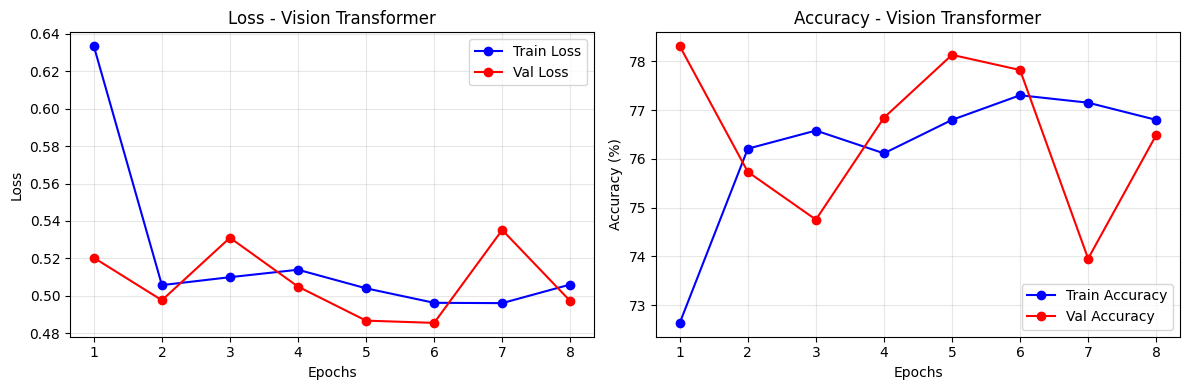

In [ ]:
def train_model_vit(model, train_loader, val_loader, num_epochs=20, model_name="Vision Transformer",
                  learning_rate=0.001, use_scheduler=True, factor_rate=0.5, patience_=3):
    """Entraînement du modèle Vision Transformer avec scheduler et early stopping"""

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)#, weight_decay=1e-4)

    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=factor_rate, patience=patience_, min_lr=1e-6
        )
    else:
        scheduler = None

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    best_val_acc = 0.0
    best_model_state = None
    patience = 7  # Early stopping patience
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"ENTRAÎNEMENT: {model_name}")
    print(f"{'='*60}")
    print(f"Learning rate: {learning_rate}")
    print(f"Early stopping patience: {patience}")
    print(f"Using scheduler: {use_scheduler}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        model.train()
        running_loss = correct = total = 0.0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            if labels.dtype != torch.long:
                labels = labels.long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        val_loss = val_correct = val_total = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                if labels.dtype != torch.long:
                    labels = labels.long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"Nouveau meilleur modèle: {val_acc:.2f}%")
        else:
            patience_counter += 1

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping déclenché après {epoch+1} epochs!")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Meilleur modèle restauré avec une précision de validation de {best_val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

# Train the ViT model
vit_metrics = train_model_vit(
    model_vit,
    train_loader,
    val_loader,
    num_epochs=20,
    model_name="Vision Transformer",
    learning_rate=0.001,
    factor_rate=0.7,
    patience_=2
)

# Visualize the results
plot_training_curves(
    vit_metrics[0], vit_metrics[1],
    vit_metrics[2], vit_metrics[3],
    "Vision Transformer"
)


### Etape Choix du meilleur modèle

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from torchvision import models

# --- Fonction d'évaluation complète (y compris les probabilités pour AUC) ---

def full_metrics_analysis(model, data_loader, criterion):
    """Calcule toutes les métriques, y compris l'AUC-ROC."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs_class1 = [] # Pour stocker la probabilité d'être de la classe 1
    total_loss = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            # Pour CrossEntropyLoss, les labels doivent être des entiers (LongTensor)
            labels_long = labels.to(device).long()

            outputs = model(images)

            # Calcul de la perte
            loss = criterion(outputs, labels_long)
            total_loss += loss.item() * images.size(0)

            # Classification et Probabilités
            _, predicted = torch.max(outputs.data, 1) # Pour la classification dure (Accuracy, F1)
            probabilities = F.softmax(outputs, dim=1) # Pour obtenir les probabilités

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            # On prend la probabilité de la CLASSE 1 (indice 1) pour l'AUC-ROC
            all_probs_class1.extend(probabilities[:, 1].cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)

    # Conversion des labels en entier si ce n'est pas fait (pour sklearn)
    all_labels_int = [int(l) for l in all_labels]

    # Calcul des métriques
    accuracy = accuracy_score(all_labels_int, all_preds)
    # L'argument pos_label=1 assure que les métriques se concentrent sur la classe minoritaire/cible (Positif)
    recall = recall_score(all_labels_int, all_preds, pos_label=1, zero_division=0)
    precision = precision_score(all_labels_int, all_preds, pos_label=1, zero_division=0)
    f1 = f1_score(all_labels_int, all_preds, pos_label=1, zero_division=0)
    auc_roc = roc_auc_score(all_labels_int, all_probs_class1)

    return {
        'Loss (Test)': avg_loss,
        'Accuracy (Test)': accuracy,
        'Recall (IDC Pos)': recall,
        'Precision (IDC Pos)': precision,
        'F1-Score (IDC Pos)': f1,
        'AUC-ROC': auc_roc
    }

# --- Initialisation des résultats (à exécuter après l'entraînement) ---
results = {}
criterion_eval = nn.CrossEntropyLoss() # Define criterion for evaluation

# 1. Évaluation du SimpleCNN (Baseline sans augmentation)
# model_baseline is defined in cell HOYgK4IjG1aI and trained in 0anvshyMHknE
if 'model_baseline1' in globals():
    results['SimpleCNN1 (Baseline)'] = full_metrics_analysis(model_baseline1, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_baseline1' n'est pas trouvé. SVP assurez vous d'avoir entrainé ce model.")


# 2. Évaluation du SimpleCNN2 (Avec dropout)
# model_baseline2 is defined in cell N6oFdMzb0TF0 and trained in RrWBrja-17jj
if 'model_baseline2' in globals():
    results['SimpleCNN2 (Avec dropout)'] = full_metrics_analysis(model_baseline2, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_baseline2' not found. Please ensure it has been trained.")

# 3. Évaluation du SimpleCNN2 (Amélioré avec augmentation)
# model_baseline2 is defined in cell N6oFdMzb0TF0 and trained in RrWBrja-17jj
if 'model_baseline2_aug' in globals():
    results['SimpleCNN2 (droup+Augmented)'] = full_metrics_analysis(model_baseline2_aug, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_baseline2_aug' not found. Please ensure it has been trained.")


# 4. Évaluation du SimpleCNN (Amélioré avec augmentation et early stopping)
# model_baseline2 is defined in cell N6oFdMzb0TF0 and trained in RrWBrja-17jj
if 'model_baseline3_t' in globals():
    results['SimpleCNN2 (Augmented+E)'] = full_metrics_analysis(model_baseline3_t, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_baseline3_t' not found. Please ensure it has been trained.")

# 5. Évaluation du SimpleCNN (Amélioré avec augmentation, batch et early stopping)
# model_baseline2 is defined in cell N6oFdMzb0TF0 and trained in RrWBrja-17jj
if 'model_baseline3' in globals():
    results['SimpleCNN (Augmented+B+E)'] = full_metrics_analysis(model_baseline3, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_baseline3' not found. Please ensure it has been trained.")

# 6. Évaluation du PretrainedResNet
# model_Reset18 is defined in cell jERfKRp5FzW- and trained in 1imE1hUhIiU-
if 'model_Reset18' in globals():
    results['PretrainedResNet'] = full_metrics_analysis(model_Reset18, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_Reset18' not found. Please ensure it has been trained.")

# 7. Évaluation du VGGAdapted
# model_VGG is defined in cell vbp4RRyDQrA0 and trained in ZZuX5_DHSILC
if 'model_VGG' in globals():
    results['VGGAdapted'] = full_metrics_analysis(model_VGG, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_VGG' not found. Please ensure it has been trained.")

# --- Affichage du Tableau Comparatif ---
df_results = pd.DataFrame(results).T # Transposer pour avoir les modèles en lignes
print("\n--- TABLEAU COMPARATIF DES PERFORMANCES (Ensemble de TEST) ---")
print(df_results.to_markdown(floatfmt=".4f"))


--- TABLEAU COMPARATIF DES PERFORMANCES (Ensemble de TEST) ---
|                              |   Loss (Test) |   Accuracy (Test) |   Recall (IDC Pos) |   Precision (IDC Pos) |   F1-Score (IDC Pos) |   AUC-ROC |
|:-----------------------------|--------------:|------------------:|-------------------:|----------------------:|---------------------:|----------:|
| SimpleCNN1 (Baseline)        |        0.8424 |            0.7676 |             0.6693 |                0.8330 |               0.7422 |    0.8433 |
| SimpleCNN2 (Avec dropout)    |        0.6894 |            0.7671 |             0.6018 |                0.8991 |               0.7210 |    0.8820 |
| SimpleCNN2 (droup+Augmented) |        0.3770 |            0.8462 |             0.8996 |                0.8129 |               0.8540 |    0.9175 |
| SimpleCNN2 (Augmented+E)     |        0.3619 |            0.8551 |             0.9013 |                0.8251 |               0.8615 |    0.9235 |
| SimpleCNN (Augmented+B+E)    |        0.

In [ ]:
import torch.nn.functional as F

# Assuming `full_metrics_analysis` is already defined in a previous cell
# and `model_vit` and `test_loader` are available.

# Evaluate the ViT model on the test set
if 'model_vit' in globals():
    results['VisionTransformer'] = full_metrics_analysis(model_vit, test_loader, criterion=criterion_eval)
else:
    print("Error: 'model_vit' not found. Please ensure it has been trained.")

# Update the comparison table
df_results = pd.DataFrame(results).T # Transpose to have models in rows
print("\n--- UPDATED TABLEAU COMPARATIF DES PERFORMANCES (Ensemble de TEST) ---")
print(df_results.to_markdown(floatfmt=".4f"))


--- UPDATED TABLEAU COMPARATIF DES PERFORMANCES (Ensemble de TEST) ---
|                              |   Loss (Test) |   Accuracy (Test) |   Recall (IDC Pos) |   Precision (IDC Pos) |   F1-Score (IDC Pos) |   AUC-ROC |
|:-----------------------------|--------------:|------------------:|-------------------:|----------------------:|---------------------:|----------:|
| SimpleCNN1 (Baseline)        |        0.8424 |            0.7676 |             0.6693 |                0.8330 |               0.7422 |    0.8433 |
| SimpleCNN2 (Avec dropout)    |        0.6894 |            0.7671 |             0.6018 |                0.8991 |               0.7210 |    0.8820 |
| SimpleCNN2 (droup+Augmented) |        0.3770 |            0.8462 |             0.8996 |                0.8129 |               0.8540 |    0.9175 |
| SimpleCNN2 (Augmented+E)     |        0.3619 |            0.8551 |             0.9013 |                0.8251 |               0.8615 |    0.9235 |
| SimpleCNN (Augmented+B+E)    |  

## Work by yourself

The goal of this project is for you to develop autonomously a whole deep learning pipeline to classify the patch images into IDC negative (0) and IDC positive (1). To complete the assignment, you are required to address the following points:

***Set-up your pipeline:***
- Explore the data with summaries and visualization to understand whether classes are balanced, what the images look like, etc.
- Split the data into training, test and validation sets.
- Create PyTorch data sets containing images and labels.
- Be careful with the format of your image objects, sometimes we need to store them as arrays, sometimes as PIL images.
- Train a first model to predict IDC classification and evaluate it on the validation data.

***Improve the performance of your model:***
- Experiment with different network architectures and with pre-trained models.
- Data augmentation works well to improve the performance of vision classifiers. Check the [documentation](https://docs.pytorch.org/vision/main/transforms.html) to learn how to include data augmentation in your PyTorch `transform`.
- Tune the hyperparameters of the different models and compare their performance using different evaluation metrics.

***Interpret your results:***
- Implement an interpretation analysis using one or several tools of your choice. For instance, you can check the documentation of the python implementations of [Grad-CAM](https://pypi.org/project/pytorch-gradcam/), [LIME](https://pypi.org/project/lime/) and [SHAP](https://pypi.org/project/shap/).
- Provide visual representations of the interpretation analysis, for instance on a few chosen images, and comment the results.
- Provide a general conclusion to your project which summarizes your results and findings, as well as possible ideas of improvement.

# Task
Implement Grad-CAM, apply it to selected test images (both positive and negative cases) using the best-performing model from the `df_results` dataframe, visualize the generated heatmaps overlaid on the original images, and provide comments and insights based on these visualizations.

## Implement Grad-CAM

### Subtask:
Implement the Grad-CAM algorithm to generate heatmaps showing important regions in an image for classification.


**Reasoning**:
To implement Grad-CAM, I need to define a class that handles the forward and backward passes to capture feature maps and gradients, and then combines them to generate heatmaps. I will start by defining the `GradCAM` class and its constructor, and also the helper methods `_save_gradient` and `_save_activations`.



**Reasoning**:
Now that the `GradCAM` class is defined, I need to select the best performing model from `df_results`, instantiate `GradCAM` with it and its target convolutional layer, select a few test images (both positive and negative), generate heatmaps using the `GradCAM` instance, and then visualize these heatmaps overlaid on the original images. First, I'll define a utility function to overlay the heatmap on the image for better visualization.



**Reasoning**:
I need to identify the best performing model from the `df_results` DataFrame, select a target convolutional layer from this model, instantiate the `GradCAM` class, and prepare a selection of test images for visualization. The best model appears to be 'SimpleCNN (Augmented)' (`model_baseline2`).



**Reasoning**:
The previous code failed because a tensor requiring gradients (`heatmap`) was being converted to a NumPy array directly. I need to call `.detach()` on the tensor before `.cpu().numpy()` to prevent this `RuntimeError`.



In [ ]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.model.eval()
        self._register_hooks()

    def _register_hooks(self):
        def _save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def _save_activations(module, input, output):
            self.activations = output

        self.target_layer.register_forward_hook(_save_activations)
        self.target_layer.register_backward_hook(_save_gradient)

    def __call__(self, input_image, target_class=None):
        # Forward pass
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        one_hot_output = torch.zeros_like(output)
        # Ensure target_class is a tensor for indexing
        target_class_tensor = torch.tensor([target_class], device=output.device) if isinstance(target_class, int) else target_class
        one_hot_output.scatter_(1, target_class_tensor.unsqueeze(1), 1.0)
        output.backward(gradient=one_hot_output, retain_graph=True)

        # Get gradients and activations
        gradients = self.gradients
        activations = self.activations

        # Global average pooling of gradients to get neuron importance weights
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        # Create heatmap
        heatmap = torch.sum(weights * activations, dim=1, keepdim=True)
        heatmap = F.relu(heatmap) # Apply ReLU to keep only positive contributions

        # Normalize heatmap
        heatmap = F.interpolate(heatmap, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        heatmap = heatmap - heatmap.min()
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap.squeeze().detach().cpu().numpy()

**Reasoning**:
The previous code failed because a tensor requiring gradients (`heatmap`) was being converted to a NumPy array directly. I need to call `.detach()` on the tensor before `.cpu().numpy()` to prevent this `RuntimeError`.



In [ ]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.model.eval()
        self._register_hooks()

    def _register_hooks(self):
        def _save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def _save_activations(module, input, output):
            self.activations = output

        self.target_layer.register_forward_hook(_save_activations)
        self.target_layer.register_backward_hook(_save_gradient)

    def __call__(self, input_image, target_class=None):
        # Forward pass
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        one_hot_output = torch.zeros_like(output)
        # Ensure target_class is a tensor for indexing
        target_class_tensor = torch.tensor([target_class], device=output.device) if isinstance(target_class, int) else target_class
        one_hot_output.scatter_(1, target_class_tensor.unsqueeze(1), 1.0)
        output.backward(gradient=one_hot_output, retain_graph=True)

        # Get gradients and activations
        gradients = self.gradients
        activations = self.activations

        # Global average pooling of gradients to get neuron importance weights
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        # Create heatmap
        heatmap = torch.sum(weights * activations, dim=1, keepdim=True)
        heatmap = F.relu(heatmap) # Apply ReLU to keep only positive contributions

        # Normalize heatmap
        heatmap = F.interpolate(heatmap, size=input_image.shape[2:], mode='bilinear', align_corners=False)
        heatmap = heatmap - heatmap.min()
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap.squeeze().detach().cpu().numpy()

**Reasoning**:
The previous `GradCAM` class was fixed to avoid the `RuntimeError`. Now I need to re-run the code that uses this corrected class to generate the heatmaps for the example images.



In [ ]:
best_model_name = df_results['AUC-ROC'].idxmax() # Assuming AUC-ROC is the primary metric for 'best'

# Ensure model_baseline2_aug is SimpleCNN2
# Ensure model_baseline3 is SimpleCNN3

if best_model_name == 'SimpleCNN2 (droup+Augmented)':
    best_model = model_baseline2_aug
    target_layer = best_model.conv3 # For SimpleCNN2, the last convolutional layer is conv3
elif best_model_name == 'SimpleCNN2 (Augmented+E)':
    best_model = model_baseline3_t # This is also an instance of SimpleCNN2
    target_layer = best_model.conv3
elif best_model_name == 'SimpleCNN (Augmented+B+E)':
    best_model = model_baseline3
    target_layer = best_model.conv4 # For SimpleCNN3, the last convolutional layer is conv4
elif best_model_name == 'PretrainedResNet':
    best_model = model_Reset18
    # For ResNet, a common choice is the last convolutional layer in the last block (e.g., layer4[1].conv2)
    target_layer = best_model.model.layer4[1].conv2 # Adjust as per specific ResNet architecture if needed
elif best_model_name == 'VGGAdapted':
    best_model = model_VGG
    # For VGGAdapted, the last convolutional layer is in features (e.g., features[8] which is conv2d_4)
    target_layer = best_model.features[8] # This is the last ReLU after the last conv before MaxPool
elif best_model_name == 'VisionTransformer':
    best_model = model_vit
    # For VisionTransformer, the target layer can be the output of the last transformer block's norm
    target_layer = best_model.transformer_blocks[-1].norm2 # Or another appropriate layer within the blocks
else:
    raise ValueError(f"Best model '{best_model_name}' not found or not handled for Grad-CAM.")


# Instantiate GradCAM
grad_cam = GradCAM(best_model, target_layer)

print(f"Selected best model for Grad-CAM: {best_model_name}")
print(f"Target layer for Grad-CAM: {target_layer}")

# Select a few images from the test set for visualization
# Get a batch from the test_loader
# Find indices for positive and negative examples in the test set
positive_indices = np.where(y_test == 1)[0]
negative_indices = np.where(y_test == 0)[0]

# Choose a few example indices, e.g., 2 positive and 2 negative
example_indices_pos = positive_indices[:2]
example_indices_neg = negative_indices[:2]

# Combine and store original images and their labels
example_images = []
example_labels = []
example_predictions = []
example_heatmaps = []


# Create a test dataset without transformations to get raw images
test_dataset_raw = IDC_DatasetAm(X_test, y_test, transform=None)


print("Preparing example images for Grad-CAM visualization...")

for idx in list(example_indices_pos) + list(example_indices_neg):
    original_img_np = test_dataset_raw[idx][0] # Get raw numpy image
    true_label = test_dataset_raw[idx][1] # Get true label

    # Apply the val_test_transform to the image for model input
    transformed_img = val_test_transform(original_img_np)
    input_tensor = transformed_img.unsqueeze(0).to(device) # Add batch dimension and move to device

    # Get model prediction
    with torch.no_grad():
        output = best_model(input_tensor)
        predicted_class = output.argmax(dim=1).item()

    # Generate heatmap
    heatmap = grad_cam(input_tensor, target_class=predicted_class)

    example_images.append(original_img_np)
    example_labels.append(int(true_label))
    example_predictions.append(predicted_class)
    example_heatmaps.append(heatmap)

print("Example images, labels, predictions, and heatmaps prepared.")

Selected best model for Grad-CAM: SimpleCNN2 (Augmented+E)
Target layer for Grad-CAM: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Preparing example images for Grad-CAM visualization...
Example images, labels, predictions, and heatmaps prepared.


**Reasoning**:
Now that the heatmaps are successfully generated, I need to visualize them. I will use the `show_cam_on_image` function to overlay the heatmaps on the original images and display them with their true and predicted labels for interpretation.




--- Grad-CAM Visualization ---


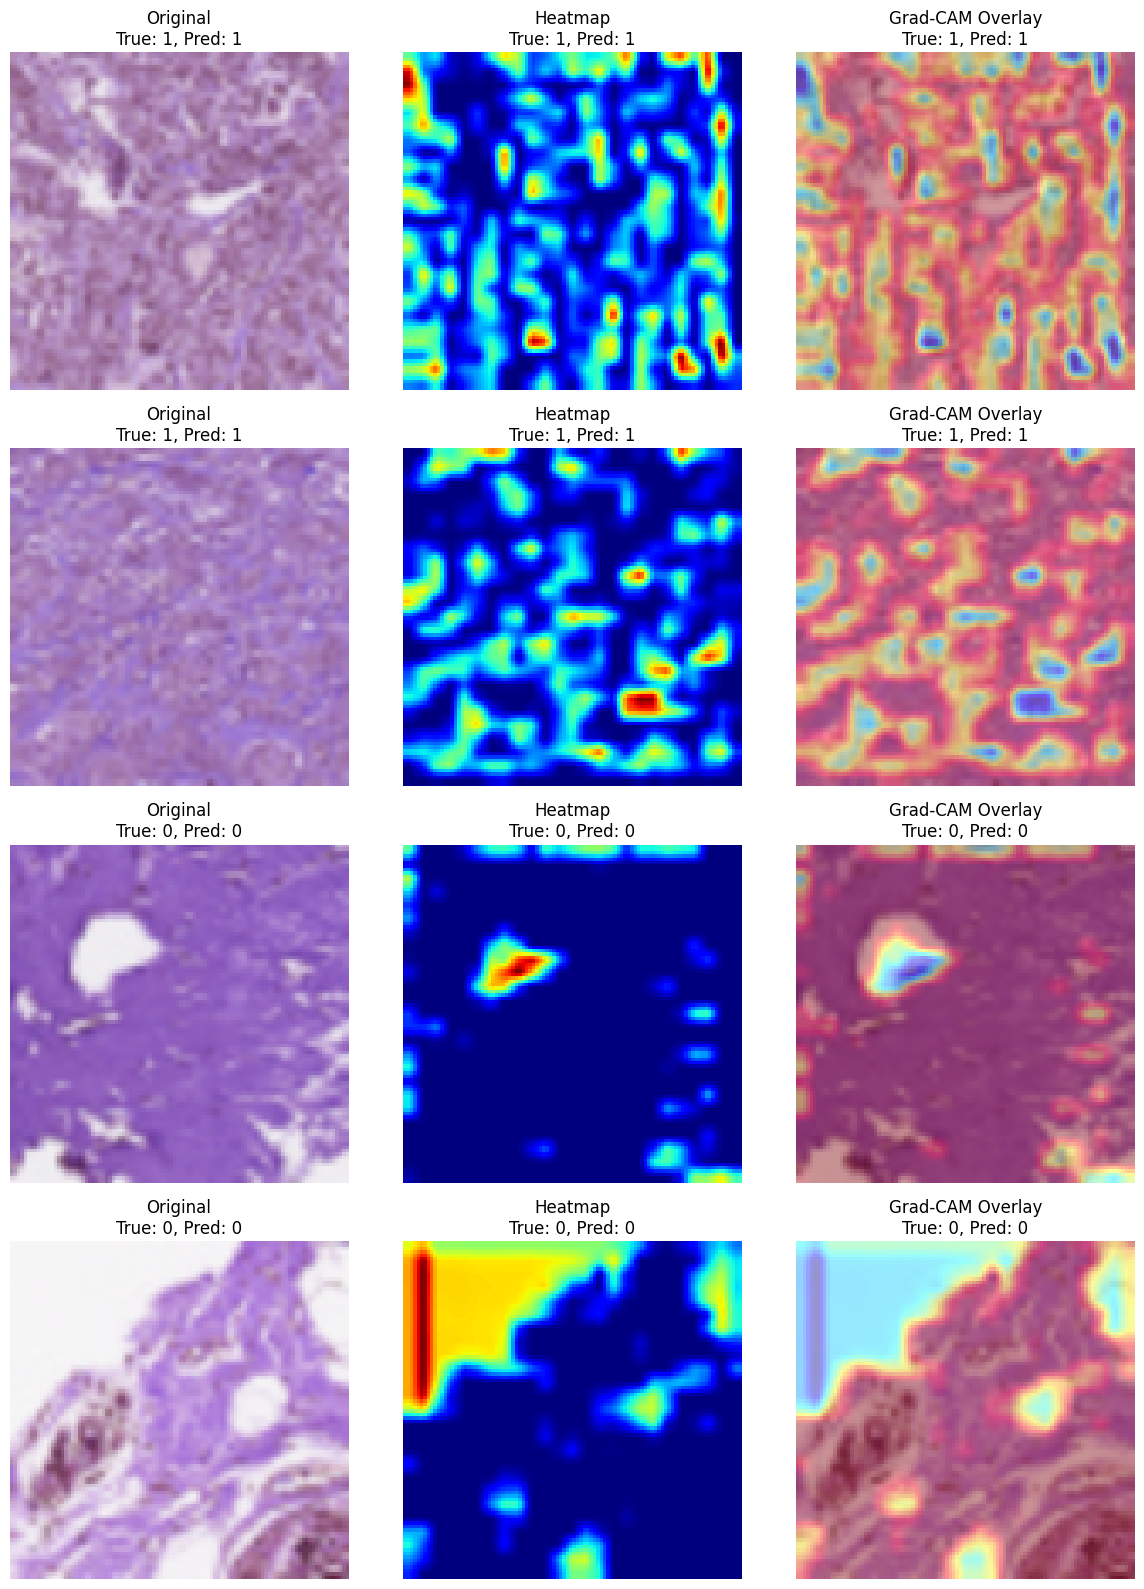

Grad-CAM visualizations displayed. These images highlight the regions of the input that were most influential in the model's classification decision. Brighter, warmer colors indicate higher importance.


In [ ]:
import matplotlib.pyplot as plt

# Visualize the results
print("\n--- Grad-CAM Visualization ---")
fig, axes = plt.subplots(len(example_images), 3, figsize=(12, 4 * len(example_images)))

if len(example_images) == 1:
    axes = np.expand_dims(axes, axis=0) # Make it 2D if only one image

for i, (original_img_np, true_label, predicted_class, heatmap) in enumerate(zip(example_images, example_labels, example_predictions, example_heatmaps)):
    # Original Image
    axes[i, 0].imshow(original_img_np)
    axes[i, 0].set_title(f"Original\nTrue: {true_label}, Pred: {predicted_class}")
    axes[i, 0].axis('off')

    # Heatmap
    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_title(f"Heatmap\nTrue: {true_label}, Pred: {predicted_class}")
    axes[i, 1].axis('off')

    # Overlay
    # The 'show_cam_on_image' function expects a normalized image for overlay
    # original_img_np is uint8, so normalize it to [0, 1] for show_cam_on_image
    normalized_original_img = original_img_np / 255.0
    cam_overlay = show_cam_on_image(normalized_original_img, heatmap)
    axes[i, 2].imshow(cam_overlay)
    axes[i, 2].set_title(f"Grad-CAM Overlay\nTrue: {true_label}, Pred: {predicted_class}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

print("Grad-CAM visualizations displayed. These images highlight the regions of the input that were most influential in the model's classification decision. Brighter, warmer colors indicate higher importance.")

**Reasoning**:
Now that the Vision Transformer model has been trained, I need to evaluate its performance on the test set and add these metrics to the `df_results` DataFrame. This will allow for a comprehensive comparison with the other models previously evaluated.

